# Temporal Action Localization 

## Overview

This work assesses your ability to **understand, assemble, and reason about a temporal action localization pipeline under computational constraints**, rather than implementing deep learning models from scratch.

You will work with the THUMOS14 dataset and a pre-extracted I3D feature representation to:
- Understand how video data is represented and processed for temporal action localization
- Train a model under GPU memory constraints (simulating a 16GB GPU limit)
- Evaluate model performance and analyze errors
- Conduct a controlled ablation study


Following is the directory structure for this coursework. You should not modify the folder structure, you can add new folders or files if needed, but do not change the existing structure.

```
ECS797_Assignment3_ActionLocalization/
├── temporal_action_localization_coursework.ipynb  # Main coursework notebook
├── configs/
│   └── thumos_i3d.yaml              # resource training config
├── data/
│   └── thumos/
│       ├── annotations/
│       │   └── thumos14.json                     # Dataset annotations
│       └── i3d_features/                         # Pre-extracted I3D features
│           ├── video_test_0000004.npy
│           ├── ...                               
│           ├── video_validation_0000001.npy
│           └── ...                               
├── libs/                                          # Provided library code, do not modify
│   ├── __init__.py
│   ├── core/
│   ├── datasets/
│   ├── modeling/
│   └── utils/
├── ckpt/                                         # Output folder for checkpoints
└── visualizations/                               # Output folder for visualizations
```

## Setup and Imports

Run this cell first to set up the environment and verify all dependencies.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
from pathlib import Path
from pprint import pprint
import time
import datetime
from collections import defaultdict

import torch
import torch.nn as nn
import torch.utils.data
from torch.utils.tensorboard import SummaryWriter

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("\nSetup complete!")

[HAMI-core Msg(1608:140303128751424:libvgpu.c:839)]: Initializing.....
[HAMI-core Warn(1608:140303128751424:multiprocess_memory_limit.c:548)]: Kick dead proc 865
2026-05-07 14:44:00.376186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 14:44:00.388090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778165040.400466    1608 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778165040.404684    1608 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has alrea

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
GPU device: NVIDIA H200 NVL
GPU memory: 16.00 GB

Setup complete!


[HAMI-core Msg(1608:140303128751424:libvgpu.c:855)]: Initialized


---
# Part A: Understanding Temporal Action Localization

In this section, you will explore the THUMOS14 dataset and understand how video data is represented for temporal action localization tasks.

## A1: Feature-Time Alignment and Dataset Statistics

Load and inspect the dataset annotations and video features to understand the data representation. You will also compute dataset-level statistics across **both** the validation and test splits.

In [2]:
from pathlib import Path

root = Path.cwd()
print("Current folder:", root)
print("Notebook files:", [p.name for p in root.glob("*.ipynb")])
print("Config exists:", (root / "configs" / "thumos_i3d.yaml").exists())
print("JSON exists:", (root / "data" / "thumos" / "annotations" / "thumos14.json").exists())

feat_dir = root / "data" / "thumos" / "i3d_features"
print("Feature dir exists:", feat_dir.exists())
if feat_dir.exists():
    feats = list(feat_dir.glob("*.npy"))
    print("Number of feature files:", len(feats))
    print("First 3 feature files:", [p.name for p in feats[:3]])

Current folder: /home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization
Notebook files: ['temporal_action_localization_coursework-Copy1.ipynb']
Config exists: True
JSON exists: True
Feature dir exists: False


In [3]:
from pathlib import Path

root = Path.cwd()
for p in root.rglob("*.npy"):
    print(p)
    break

/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/data/i3d_features/video_validation_0000183.npy


In [4]:
for p in root.rglob("*i3d*"):
    print(p)

/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/configs/thumos_i3d.yaml
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/ckpt/thumos_i3d_low_resource_2026-05-06 10:47:35
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/ckpt/thumos_i3d_low_resource_2026-05-07 13:58:03
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/ckpt/thumos_i3d_low_resource_2026-05-07 13:29:54
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/data/i3d_features
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/configs/.ipynb_checkpoints/thumos_i3d-checkpoint.yaml


In [5]:
# Load the THUMOS14 annotation file
annotation_file = './data/thumos/annotations/thumos14.json'
with open(annotation_file, 'r') as f:
    thumos_data = json.load(f)

# Examine a sample video
sample_video_id = 'video_test_0000004'
sample_video = thumos_data['database'][sample_video_id]

print(f"Duration: {sample_video['duration']} seconds")
print(f"FPS: {sample_video['fps']}")
print(f"\nAnnotations:")
for i, ann in enumerate(sample_video['annotations']):
    print(f"  {i+1}. {ann['label']}: {ann['segment']} sec (frames {ann['segment(frames)']}), label_id={ann['label_id']}")

Duration: 33.83 seconds
FPS: 30.0

Annotations:
  1. CricketBowling: [0.2, 1.1] sec (frames [6.0, 33.0]), label_id=5
  2. CricketBowling: [11.4, 12.2] sec (frames [342.0, 366.0]), label_id=5
  3. CricketBowling: [18.6, 20.8] sec (frames [558.0, 624.0]), label_id=5
  4. CricketBowling: [28.3, 29.7] sec (frames [849.0, 891.0]), label_id=5
  5. CricketShot: [1.0, 1.5] sec (frames [30.0, 45.0]), label_id=6
  6. CricketShot: [20.8, 22.3] sec (frames [624.0, 669.0]), label_id=6
  7. CricketShot: [30.3, 31.7] sec (frames [909.0, 951.0]), label_id=6


In [6]:
# TODO (A1.1): Load the feature file for video 'video_test_0000004' from the THUMOS14
# i3d_features directory, then print its shape, dtype, and basic statistics (min, max, mean).

feature_path = './data/i3d_features/video_test_0000004.npy'
features = np.load(feature_path)

print("Shape:", features.shape)
print("Dtype:", features.dtype)
print("Min:", features.min())
print("Max:", features.max())
print("Mean:", features.mean())

Shape: (249, 2048)
Dtype: float32
Min: 0.0
Max: 2.9101415
Mean: 0.2045092


Total number of validation videos: 50
Total number of test videos: 50
Min stride: 4.002684115239295
Max stride: 4.252380952380952
Mean stride: 4.0226559540492115


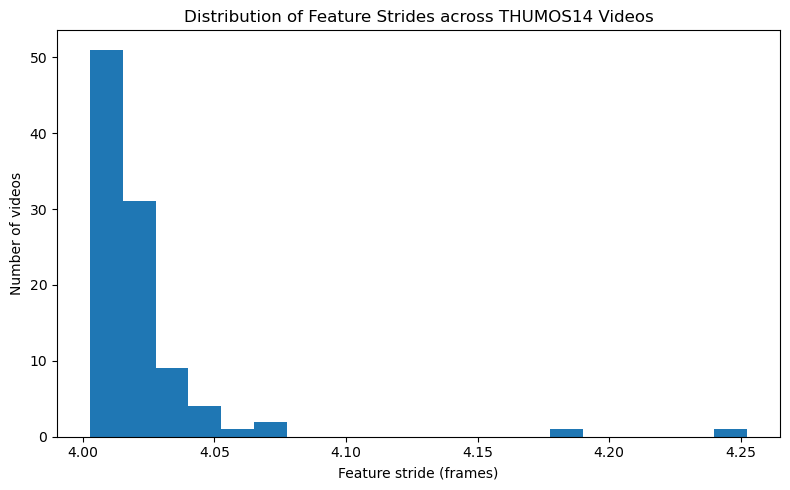

In [7]:


feature_dir = './data/i3d_features/'
strides = []
n_val = 0
n_test = 0

for fname in os.listdir(feature_dir):
    if not fname.endswith('.npy'):
        continue

    video_id = fname.replace('.npy', '')

    if video_id not in thumos_data['database']:
        continue

    # count validation / test
    if video_id.startswith('video_validation'):
        n_val += 1
    elif video_id.startswith('video_test'):
        n_test += 1

    # load feature file
    feat_path = os.path.join(feature_dir, fname)
    features = np.load(feat_path)

    T = features.shape[0]  # number of temporal feature steps

    # get video metadata
    video_info = thumos_data['database'][video_id]
    duration = video_info['duration']
    fps = video_info['fps']

    # total frames in original video
    num_frames = duration * fps

    # feature stride in frames
    stride = num_frames / T
    strides.append(stride)

strides = np.array(strides)

print("Total number of validation videos:", n_val)
print("Total number of test videos:", n_test)
print("Min stride:", strides.min())
print("Max stride:", strides.max())
print("Mean stride:", strides.mean())

plt.figure(figsize=(8, 5))
plt.hist(strides, bins=20)
plt.title("Distribution of Feature Strides across THUMOS14 Videos")
plt.xlabel("Feature stride (frames)")
plt.ylabel("Number of videos")
plt.tight_layout()
plt.savefig('./visualizations/feature_stride_hist.png')
plt.show()

### A1 Questions 

**Q1**: What does each dimension of the feature tensor represent? Be specific about what the shape `(T, D)` means in the context of this video.

**Your answer:**
```
[Write your answer here]
The feature vector has a shape (T , D) where T represents the number of temporal steps basically the number of feature vectors extracted from the video and D represents the feature dimension.We are not using raw video as an input.The video is converted into I3D features using convolution so when we say t=249 or something it means the video is represented by those number of features and d is the dimension of that feature vector.   ...remeber for 2 you have to make the changes inone of the file s like she said  like one training epoch or something and you have to change a parameter or hyper parameter t in the model architecture to make correct output.

```

**Q2** : Based on your per-video stride computation (A1.2), report the stride distribution and explain how temporal annotations in **seconds** are converted to feature indices. Show the formula and an example calculation using `video_test_0000004`.

**Your answer:**
```
[Write your answer here – include the formula and worked example]
From the computation, the feature stride is approximately 4 frames with a min value of 4.00 , max value of 4.25 and mean value of 4.02 correct upto 2 decimal places.It indicates that each feature vector correponds to roughly 4 original video frames.
To convert temporal annotations from seconds to feature indices, we convert time to frame index using the fps rate and then divide by the feature stride
Formula feature index= (time in seconds * fps)/ stride
 example for an action starting at 0.2 secs 
  fps = 30
  sride = 4
  frame index = 0.2 * 30 = 6
  feature index= 6/4 = 1.5  which is approximate to feature index 2.
  for an end time of 1.1 sec
  frame index = 1.1 * 30 = 33
  feature index = 33/4 = 8.25 which is approximately 8
  so the action spans approximately from feature index 2 to 8.
This approximation introduced by feature stride reduces temporal precision.We might not get the exact boundaries because of this temporal downsampling.


```

**Q3**: Why might different videos have different feature strides? What implications does a non-uniform stride have for the model's temporal resolution, and how does ActionFormer handle this (refer to the paper)?

**Your answer:**
```
[Write your answer here]
Different videos may have different feature strides due to variations in feature extraction process  like rounding  and temporal sampling. Even with same frame rates the conversion from raw frames to features involve interpolation or segmentation leading to small differences in stride. A non uniform stride means that each feature vector may correspond to slightly different durations across videos which can effect the precision temporal boundary.THis makes it harder to map predicted feature indices back to exact frame level timestamps.
Action former addresses ths by operating in feature space rahter than relying on exact frame level time stamps.It predicts action boundaries as distances relative to each feature location which allows it to adapt to small varationsin temporal resolutions. 

```

## A2: Annotation Statistics and Class Distribution

You will **compute and visualise** properties of the dataset that illuminate why temporal action localisation is harder than action classification.

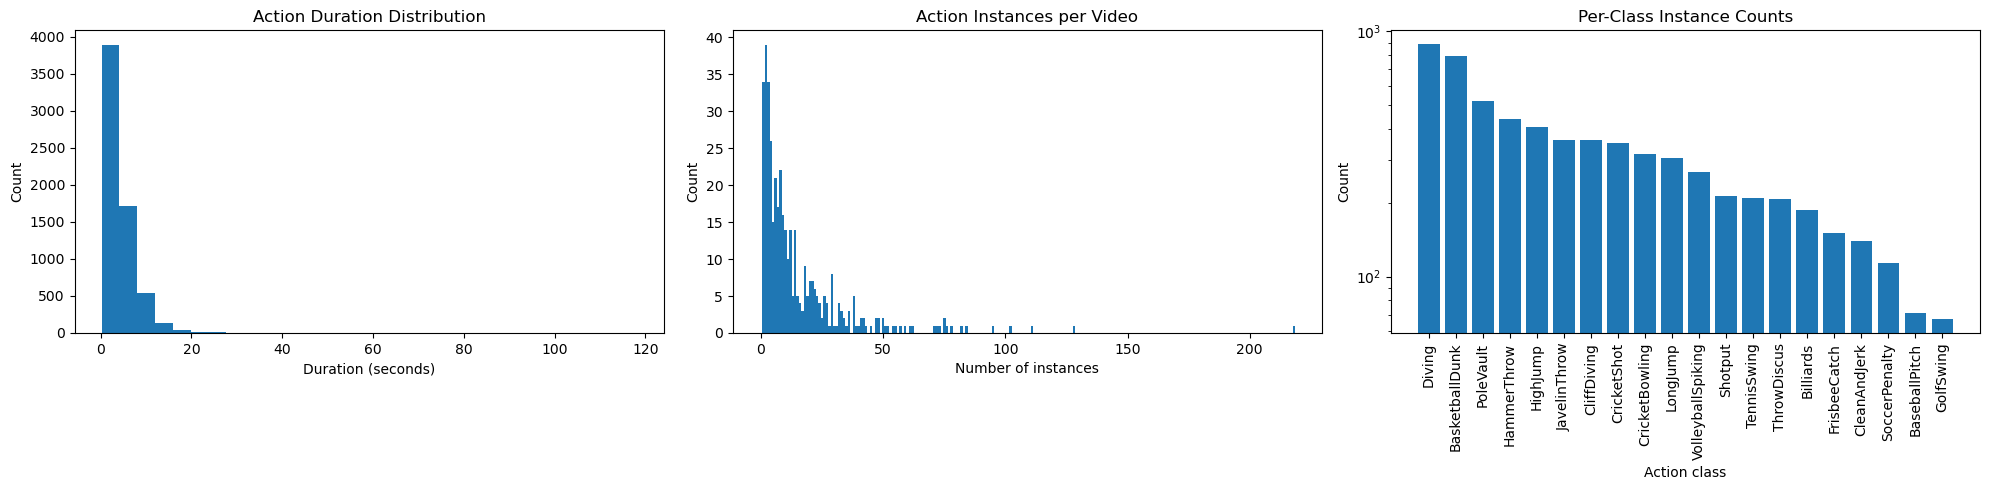

Top 3 classes with the longest average duration:
  CleanAndJerk: 11.90 seconds
  GolfSwing: 8.64 seconds
  HammerThrow: 7.46 seconds

Top 3 classes with the shortest average duration:
  CricketShot: 1.43 seconds
  CricketBowling: 1.74 seconds
  BasketballDunk: 1.80 seconds


In [8]:

from collections import defaultdict, Counter

annotation_file = './data/thumos/annotations/thumos14.json'
with open(annotation_file, 'r') as f:
    thumos_data = json.load(f)

durations = []
instances_per_video = []
class_counts = Counter()
class_duration_sum = defaultdict(float)
class_duration_count = defaultdict(int)

for video_id, video_info in thumos_data['database'].items():
    anns = video_info.get('annotations', [])
    instances_per_video.append(len(anns))
    
    for ann in anns:
        label = ann['label']
        start, end = ann['segment']
        dur = end - start
        
        durations.append(dur)
        class_counts[label] += 1
        class_duration_sum[label] += dur
        class_duration_count[label] += 1

# Average duration per class
class_avg_duration = {
    cls: class_duration_sum[cls] / class_duration_count[cls]
    for cls in class_duration_count
}

# Top-3 longest and shortest average-duration classes
longest_3 = sorted(class_avg_duration.items(), key=lambda x: x[1], reverse=True)[:3]
shortest_3 = sorted(class_avg_duration.items(), key=lambda x: x[1])[:3]

# Sort class counts for cleaner plotting
sorted_class_items = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
class_names = [x[0] for x in sorted_class_items]
class_freqs = [x[1] for x in sorted_class_items]

# ---- Plotting ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) Duration distribution
# Using ~30 bins gives enough detail without making the histogram too noisy.
axes[0].hist(durations, bins=30)
axes[0].set_title('Action Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')

# (b) Instances per video
# Integer bins are appropriate because the number of action instances per video is discrete.
max_inst = max(instances_per_video)
axes[1].hist(instances_per_video, bins=np.arange(-0.5, max_inst + 1.5, 1))
axes[1].set_title('Action Instances per Video')
axes[1].set_xlabel('Number of instances')
axes[1].set_ylabel('Count')

# (c) Per-class counts
# Log scale is used on the y-axis because class frequencies can be imbalanced.
axes[2].bar(class_names, class_freqs)
axes[2].set_title('Per-Class Instance Counts')
axes[2].set_xlabel('Action class')
axes[2].set_ylabel('Count')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('./visualizations/annotation_stats.png')
plt.show()

print("Top 3 classes with the longest average duration:")
for cls, avg_dur in longest_3:
    print(f"  {cls}: {avg_dur:.2f} seconds")

print("\nTop 3 classes with the shortest average duration:")
for cls, avg_dur in shortest_3:
    print(f"  {cls}: {avg_dur:.2f} seconds")

### A2 Written Response

Based on your plots above, briefly explain **two specific challenges** that these annotation statistics reveal for temporal action localisation (as opposed to clip-level action classification). Reference specific numbers from your plots.

**Your answer:**
```
[Write your answer here – aim for 80–120 words]
The stats reveal 2 main challenges for temporal action localisation.First the actions, some of the actions are really short like cricket shot around 1.43 secs and some are very long like clean and jerk aroumd 11.9 secs. This requires the model to handle multiple temporal scales.Second there is strong class imbalance as shown by the per class count classes like diving appear more frequently than others for example golf swing.This causes the model to bias toward frequent classes and reduce performance on rare ones.Also the presence of many instances per video increases complexity compared to clip level action classification where only a single label is required. 


```

## A3: ActionFormer Architecture Tracing

You will trace the data dimensions through the ActionFormer encoder to understand how the feature pyramid is built.

In [9]:
import math
import yaml
from pathlib import Path

# Config/code locations used:
# 1) configs/thumos_i3d.yaml
#    - backbone_arch
#    - scale_factor
#    - regression_range
# 2) ActionFormer implementation:
#    - projection layers keep T unchanged
#    - stem transformer layers keep T unchanged
#    - branch uses downsampling by scale_factor=2 to build the pyramid

config_path = Path("./configs/thumos_i3d.yaml")
with open(config_path, "r") as f:
    cfg = yaml.safe_load(f)

# Try to read common config keys safely
model_cfg = cfg.get("model", cfg)

backbone_arch = model_cfg.get("backbone_arch", [2, 2, 5])
scale_factor = model_cfg.get("scale_factor", 2)
regression_range = model_cfg.get(
    "regression_range",
    [[0, 4], [4, 8], [8, 16], [16, 32], [32, 64], [64, 10000]]
)

# Interpret backbone_arch = [n_proj, n_stem, n_branch]
n_proj = backbone_arch[0]
n_stem = backbone_arch[1]
n_branch = backbone_arch[2]

print("backbone_arch:", backbone_arch)
print("scale_factor:", scale_factor)
print("regression_range:", regression_range)


def trace_actionformer_encoder(T_in: int, D_in: int = 2048) -> list:
    """
    Returns:
        List of dicts, one per stage, with keys:
            'stage': str
            'T': int
            'D': int
            'reg_range': str
    """
    stages = []

    # Read embedding dimension if present, otherwise use a common ActionFormer default
    D_model = model_cfg.get("embd_dim", model_cfg.get("n_embd", 512))

    # Input
    stages.append({
        "stage": "Input features",
        "T": T_in,
        "D": D_in,
        "reg_range": "N/A"
    })

    # Projection conv stack: temporal length unchanged
    T = T_in
    for i in range(n_proj):
        stages.append({
            "stage": f"Projection conv {i+1}",
            "T": T,
            "D": D_model,
            "reg_range": "N/A"
        })

    # Stem transformer layers: temporal length unchanged
    for i in range(n_stem):
        stages.append({
            "stage": f"Stem transformer {i+1}",
            "T": T,
            "D": D_model,
            "reg_range": "N/A"
        })

    # Pyramid levels
    # Level 0 uses current T without downsampling
    stages.append({
        "stage": "Pyramid level P0",
        "T": T,
        "D": D_model,
        "reg_range": str(regression_range[0]) if len(regression_range) > 0 else "N/A"
    })

    # Each next pyramid level downsamples by scale_factor
    for lvl in range(1, len(regression_range)):
        T = math.ceil(T / scale_factor)
        stages.append({
            "stage": f"Pyramid level P{lvl}",
            "T": T,
            "D": D_model,
            "reg_range": str(regression_range[lvl])
        })

    return stages


def print_stage_table(stages, title="Encoder Trace"):
    print(f"\n{title}")
    print("-" * 80)
    print(f"{'Stage':<25} {'T':>8} {'D':>8} {'Regression Range':>20}")
    print("-" * 80)
    for s in stages:
        print(f"{s['stage']:<25} {s['T']:>8} {s['D']:>8} {s['reg_range']:>20}")
    print("-" * 80)


trace_2304 = trace_actionformer_encoder(2304)
trace_160 = trace_actionformer_encoder(160)

print_stage_table(trace_2304, "ActionFormer Encoder Trace for T=2304")
print_stage_table(trace_160, "ActionFormer Encoder Trace for T=160")

backbone_arch: [2, 2, 5]
scale_factor: 2
regression_range: [[0, 4], [4, 8], [8, 16], [16, 32], [32, 64], [64, 10000]]

ActionFormer Encoder Trace for T=2304
--------------------------------------------------------------------------------
Stage                            T        D     Regression Range
--------------------------------------------------------------------------------
Input features                2304     2048                  N/A
Projection conv 1             2304      512                  N/A
Projection conv 2             2304      512                  N/A
Stem transformer 1            2304      512                  N/A
Stem transformer 2            2304      512                  N/A
Pyramid level P0              2304      512               [0, 4]
Pyramid level P1              1152      512               [4, 8]
Pyramid level P2               576      512              [8, 16]
Pyramid level P3               288      512             [16, 32]
Pyramid level P4               

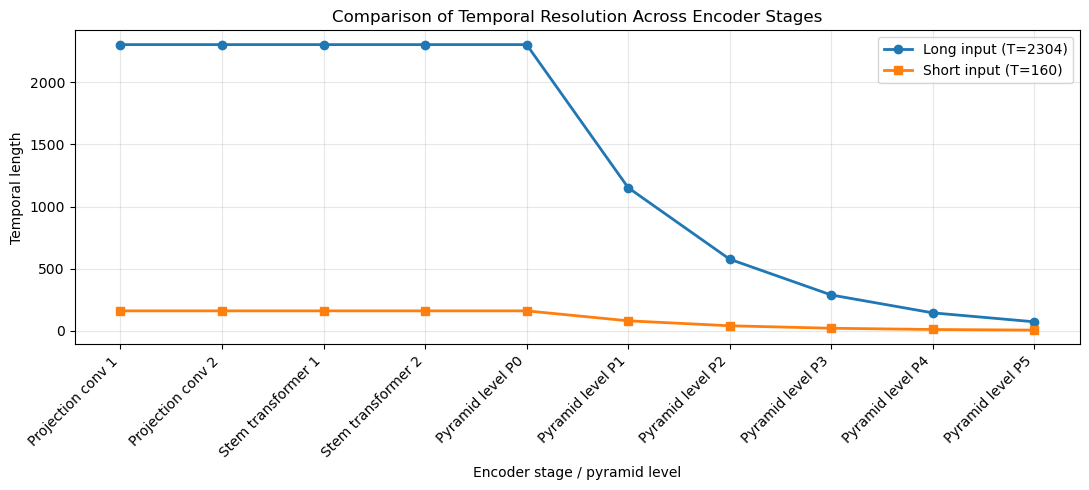

In [10]:

trace_2304 = trace_actionformer_encoder(2304)
trace_160 = trace_actionformer_encoder(160)

# Select only projection/stem/pyramid stages, excluding raw input if desired
stage_names = [s["stage"] for s in trace_2304 if s["stage"] != "Input features"]
T_2304 = [s["T"] for s in trace_2304 if s["stage"] != "Input features"]
T_160 = [s["T"] for s in trace_160 if s["stage"] != "Input features"]

plt.figure(figsize=(11, 5))
plt.plot(stage_names, T_2304, marker='o', linewidth=2, label='Long input (T=2304)')
plt.plot(stage_names, T_160, marker='s', linewidth=2, label='Short input (T=160)')

plt.title('Comparison of Temporal Resolution Across Encoder Stages')
plt.xlabel('Encoder stage / pyramid level')
plt.ylabel('Temporal length')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./visualizations/pyramid_resolution.png')
plt.show()

### A3 Written Response

From your dimension trace above, explain why the multi-scale feature pyramid is critical for detecting actions of very different durations. Use **specific numbers** from your table (e.g., the temporal resolution at the finest and coarsest levels, and their corresponding regression ranges).

**Your answer:**
```
[Write your answer here – aim for 80–120 words]
The multi-scale feature pyramid is critical because it allows the model to handle actions of very different durations using different temporal resolutions. At the finest level (P0), the temporal length is high e.g. 2304 for a long input with a regression range of [0, 4] which enables precise localisation of short actions. At the coarsest level (P5), the temporal length is much smaller e.g. 72 with a large regression range of [64, 10000] which allows the model to capture long-duration actions efficiently. This design ensures that short actions are detected with high precision while long actions are detected using broader temporal context without excessive computation.


```

---
# Part B: Training Under 16GB GPU Constraint

In this section, you will complete the training driver and configure it to work within a 16GB GPU memory constraint.

## B1: Completing the Training Driver

You need to implement the missing parts of the training pipeline. The scaffold below provides the structure.

In [11]:
import os
from pathlib import Path

root = Path.cwd()

for p in root.rglob("*nms*"):
    print(p)

/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/nms_1d_cpu.cpython-312-x86_64-linux-gnu.so
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/nms.py
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/nms_1d_cpu.egg-info
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/csrc/nms_cpu.cpp
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/.ipynb_checkpoints/nms-checkpoint.py
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/__pycache__/nms.cpython-312.pyc
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/__pycache__/nms.cpython-311.pyc
/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/dist/nms_1d_cpu-0.0.0-py3.11-linux-x86_64.egg
/home/jovyan/lost+found/action

In [12]:
for p in root.rglob("setup.py"):
    print(p)

/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/setup.py


In [13]:
for p in root.rglob("*.cpp"):
    print(p)

/home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils/csrc/nms_cpu.cpp


In [14]:
import sys
from pathlib import Path

project_root = Path.cwd()
utils_dir = project_root / "libs" / "utils"

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

print("Added to sys.path:", utils_dir)

Added to sys.path: /home/jovyan/lost+found/action recognition/ECS796_Assignment3_ActionLocalization/libs/utils


In [15]:
import nms_1d_cpu
print("nms_1d_cpu imported successfully")

nms_1d_cpu imported successfully


In [16]:
# Import necessary modules from the libs package
from libs.core import load_config
from libs.datasets import make_dataset, make_data_loader
from libs.modeling import make_meta_arch
from libs.utils import (
    train_one_epoch, save_checkpoint, make_optimizer,
    make_scheduler, fix_random_seed, ModelEma
)

In [17]:
print('==================== Training Configuration ====================')

# Path to config
config_path = './configs/thumos_i3d.yaml'

# Load config
original_cfg = load_config(config_path)

print("Original configuration:")
print(original_cfg)

==================== Training Configuration ====================
Original configuration:
{'dataset_name': 'thumos', 'train_split': ['validation'], 'val_split': ['test'], 'dataset': {'json_file': './data/thumos/annotations/thumos14.json', 'feat_folder': './data/thumos/i3d_features', 'file_prefix': None, 'file_ext': '.npy', 'num_classes': 20, 'input_dim': 2048, 'feat_stride': 4, 'num_frames': 16, 'trunc_thresh': 0.5, 'crop_ratio': [0.9, 1.0], 'max_seq_len': 2304, 'default_fps': None, 'downsample_rate': 1, 'force_upsampling': False}, 'model': {'fpn_type': 'identity', 'max_buffer_len_factor': 6.0, 'n_mha_win_size': 19, 'backbone_type': 'convTransformer', 'backbone_arch': (2, 2, 5), 'scale_factor': 2, 'regression_range': [(0, 4), (4, 8), (8, 16), (16, 32), (32, 64), (64, 10000)], 'n_head': 4, 'embd_kernel_size': 3, 'embd_dim': 512, 'embd_with_ln': True, 'fpn_dim': 512, 'fpn_with_ln': True, 'fpn_start_level': 0, 'head_dim': 512, 'head_kernel_size': 3, 'head_num_layers': 3, 'head_with_ln': Tr

In [18]:
import copy
cfg = copy.deepcopy(original_cfg)

changes = []

# Fix feature path
old = cfg['dataset']['feat_folder']
cfg['dataset']['feat_folder'] = './data/i3d_features'

# Minimal GPU-memory-focused change
old = cfg['dataset']['max_seq_len']
cfg['dataset']['max_seq_len'] = 1152


old = cfg['model']['max_seq_len']
cfg['model']['max_seq_len'] = 1152


print("\nModified configuration:")
print(cfg)




Modified configuration:
{'dataset_name': 'thumos', 'train_split': ['validation'], 'val_split': ['test'], 'dataset': {'json_file': './data/thumos/annotations/thumos14.json', 'feat_folder': './data/i3d_features', 'file_prefix': None, 'file_ext': '.npy', 'num_classes': 20, 'input_dim': 2048, 'feat_stride': 4, 'num_frames': 16, 'trunc_thresh': 0.5, 'crop_ratio': [0.9, 1.0], 'max_seq_len': 1152, 'default_fps': None, 'downsample_rate': 1, 'force_upsampling': False}, 'model': {'fpn_type': 'identity', 'max_buffer_len_factor': 6.0, 'n_mha_win_size': 19, 'backbone_type': 'convTransformer', 'backbone_arch': (2, 2, 5), 'scale_factor': 2, 'regression_range': [(0, 4), (4, 8), (8, 16), (16, 32), (32, 64), (64, 10000)], 'n_head': 4, 'embd_kernel_size': 3, 'embd_dim': 512, 'embd_with_ln': True, 'fpn_dim': 512, 'fpn_with_ln': True, 'fpn_start_level': 0, 'head_dim': 512, 'head_kernel_size': 3, 'head_num_layers': 3, 'head_with_ln': True, 'use_abs_pe': False, 'use_rel_pe': False, 'input_dim': 2048, 'num_c

In [19]:
import shutil, os
total, used, free = shutil.disk_usage(".")
print(f"Total: {total / (1024**3):.2f} GB")
print(f"Used:  {used / (1024**3):.2f} GB")
print(f"Free:  {free / (1024**3):.2f} GB")

print("\nCheckpoint folders:")
print(os.listdir("./ckpt"))

Total: 24.52 GB
Used:  9.71 GB
Free:  14.79 GB

Checkpoint folders:
['thumos_i3d_low_resource_2026-05-06 10:47:35', 'thumos_i3d_low_resource_2026-05-07 13:58:03', 'thumos_i3d_low_resource_2026-05-07 13:29:54']


In [20]:
import os

def get_folder_size(path):
    total = 0
    for root, dirs, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total

ckpt_root = "./ckpt"
folders = []

for name in os.listdir(ckpt_root):
    path = os.path.join(ckpt_root, name)
    if os.path.isdir(path):
        size_gb = get_folder_size(path) / (1024**3)
        folders.append((name, size_gb))

folders = sorted(folders, key=lambda x: x[1], reverse=True)

for name, size_gb in folders:
    print(f"{name} -> {size_gb:.2f} GB")

thumos_i3d_low_resource_2026-05-06 10:47:35 -> 3.05 GB
thumos_i3d_low_resource_2026-05-07 13:58:03 -> 0.87 GB
thumos_i3d_low_resource_2026-05-07 13:29:54 -> 0.87 GB


In [21]:
import time
import datetime
import os
from torch.utils.tensorboard import SummaryWriter
print('==================== Setup Training ====================') 
output_folder = cfg['output_folder']
os.makedirs(output_folder, exist_ok=True)

cfg_filename = 'thumos_i3d_low_resource'
ts = datetime.datetime.fromtimestamp(int(time.time()))
ckpt_folder = os.path.join(output_folder, f"{cfg_filename}_{ts}")
os.makedirs(ckpt_folder, exist_ok=True)

print(f"Checkpoint folder: {ckpt_folder}")

tb_writer = SummaryWriter(os.path.join(ckpt_folder, 'logs'))
rng_generator = fix_random_seed(cfg['init_rand_seed'], include_cuda=True)

num_gpus = len(cfg['devices'])
cfg['opt']['learning_rate'] *= num_gpus
cfg['loader']['num_workers'] *= num_gpus

==================== Setup Training ====================
Checkpoint folder: ./ckpt/thumos_i3d_low_resource_2026-05-07 14:44:07


In [22]:
# TODO (B1.3): Build dataset and dataloader

train_dataset = make_dataset(
    cfg['dataset_name'],
    True,                   # training mode
    cfg['train_split'],
    **cfg['dataset']
)

train_db_vars = train_dataset.get_attributes()
cfg['model']['train_cfg']['head_empty_cls'] = train_db_vars['empty_label_ids']

train_loader = make_data_loader(
    train_dataset,
    True,                   # training mode
    rng_generator,
    **cfg['loader']
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Number of batches: {len(train_loader)}")

Training dataset size: 50
Number of batches: 50


In [23]:
# TODO (B1.4): Build model, optimizer, and scheduler

model = make_meta_arch(cfg['model_name'], **cfg['model'])
model = nn.DataParallel(model, device_ids=cfg['devices'])

optimizer = make_optimizer(model, cfg['opt'])

num_iters_per_epoch = len(train_loader)
scheduler = make_scheduler(optimizer, cfg['opt'], num_iters_per_epoch)

print("Initializing model EMA...")
model_ema = ModelEma(model)

print("\nModel, optimizer, and scheduler initialized!")

Initializing model EMA...

Model, optimizer, and scheduler initialized!


In [24]:
import inspect
print(inspect.signature(train_one_epoch))

print(train_one_epoch.__doc__)

(train_loader, model, optimizer, scheduler, curr_epoch, model_ema=None, clip_grad_l2norm=-1, tb_writer=None, print_freq=20)
Training the model for one epoch


In [25]:
!df -h
!du -sh ./ckpt/*


Filesystem                                                                                                                                                             Size  Used Avail Use% Mounted on
overlay                                                                                                                                                                930G  529G  401G  57% /
tmpfs                                                                                                                                                                   64M     0   64M   0% /dev
tmpfs                                                                                                                                                                  1.0G   24K  1.0G   1% /tmp
none                                                                                                                                                                    64M   72K   64M   1% /tmp/vgpu
/dev/nvme1n1p1        

In [26]:
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-04-09 18:35:50"
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-04-10 15:02:38"
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-04-21 17:25:43"
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-04-21 17:27:54"
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-04-21 20:19:45"
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-04-24 13:10:53"
!rm -rf "./ckpt/thumos_i3d_low_resource_2026-05-06 23:21:25"

In [27]:
!df -h /home/jovyan
!du -sh ./ckpt/*

Filesystem      Size  Used Avail Use% Mounted on
/dev/rbd6        25G  9.8G   15G  40% /home/jovyan
3.1G	./ckpt/thumos_i3d_low_resource_2026-05-06 10:47:35
895M	./ckpt/thumos_i3d_low_resource_2026-05-07 13:29:54
895M	./ckpt/thumos_i3d_low_resource_2026-05-07 13:58:03
12K	./ckpt/thumos_i3d_low_resource_2026-05-07 14:44:07


In [28]:
# TODO (B1.5): Run the training loop and record loss curves.
#
# Requirements:
#   - Train for the configured number of epochs (respecting any early-stop setting).
#   - Populate loss_history with per-epoch values so they can be plotted in B2:
#       - 'total' (required)
#       - 'cls' and 'reg' (if available in your implementation; otherwise store None and explain)
#   - Your approach should be reproducible (do not manually copy numbers from console output).

# TODO (B1.5): Run the training loop and record loss curves.
#
# Permanent disk-safe version:
#   - Saves only ONE rolling checkpoint: latest.pth.tar
#   - Saves ONE final checkpoint at the end: epoch_XXX.pth.tar
#   - Prevents disk from filling up with many large checkpoint files

import os
import contextlib
import torch

print("\n" + "="*60)
print("Starting training...")
print("="*60)

max_epochs = cfg['opt'].get(
    'early_stop_epochs',
    cfg['opt']['epochs'] + cfg['opt']['warmup_epochs']
)

print("max_epochs =", max_epochs)

os.makedirs(ckpt_folder, exist_ok=True)

# Storage for loss curves
loss_history = {'total': [], 'cls': [], 'reg': []}

latest_ckpt_name = "latest.pth.tar"
final_ckpt_name = f"epoch_{max_epochs:03d}.pth.tar"

for epoch in range(max_epochs):
    print(f"\nEpoch [{epoch+1}/{max_epochs}]")

    # Suppress verbose internal debug prints from train_one_epoch
    with open(os.devnull, 'w') as fnull:
        with contextlib.redirect_stdout(fnull):
            out = train_one_epoch(
                train_loader,
                model,
                optimizer,
                scheduler,
                epoch,
                model_ema=model_ema,
                clip_grad_l2norm=cfg['train_cfg']['clip_grad_l2norm'],
                tb_writer=tb_writer,
                print_freq=20
            )

    total_loss = None
    cls_loss = None
    reg_loss = None

    if isinstance(out, dict):
        total_loss = out.get('total', out.get('loss', out.get('final_loss', None)))
        cls_loss = out.get('cls', out.get('cls_loss', None))
        reg_loss = out.get('reg', out.get('reg_loss', None))

    elif isinstance(out, (tuple, list)):
        if len(out) > 0:
            total_loss = out[0]
        if len(out) > 1:
            cls_loss = out[1]
        if len(out) > 2:
            reg_loss = out[2]

    loss_history['total'].append(total_loss)
    loss_history['cls'].append(cls_loss)
    loss_history['reg'].append(reg_loss)

    print(f"Recorded losses -> total: {total_loss}, cls: {cls_loss}, reg: {reg_loss}")

    save_states = {
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'state_dict_ema': model_ema.module.state_dict(),
        'scheduler': scheduler.state_dict(),
        'optimizer': optimizer.state_dict(),
        'loss_history': loss_history
    }

    # Save rolling checkpoint every 5 epochs and at final epoch.
    # This overwrites the same file, so disk usage stays constant.
    if ((epoch + 1) % 5 == 0) or ((epoch + 1) == max_epochs):
        latest_path = os.path.join(ckpt_folder, latest_ckpt_name)
        torch.save(save_states, latest_path)
        print(f"Rolling checkpoint updated: {latest_ckpt_name}")

    # Save one final named checkpoint only at the end.
    if (epoch + 1) == max_epochs:
        final_path = os.path.join(ckpt_folder, final_ckpt_name)
        torch.save(save_states, final_path)
        print(f"Final checkpoint saved: {final_ckpt_name}")

tb_writer.close()

print("Training complete!")
print("Final loss history:")
print(loss_history)


Starting training...
max_epochs = 35

Epoch [1/35]
Recorded losses -> total: 1.1942539766430855, cls: 0.8056654822826386, reg: 0.3885884965956211

Epoch [2/35]
Recorded losses -> total: 1.0591026033461093, cls: 0.7107699938863515, reg: 0.3483326128870249

Epoch [3/35]
Recorded losses -> total: 0.7977704219520092, cls: 0.5107606264203787, reg: 0.2870098017901182

Epoch [4/35]
Recorded losses -> total: 0.7903368908911943, cls: 0.49355464220046996, reg: 0.29678224474191667

Epoch [5/35]
Recorded losses -> total: 0.8486407872289419, cls: 0.5482696667313576, reg: 0.3003711232170463
Rolling checkpoint updated: latest.pth.tar

Epoch [6/35]
Recorded losses -> total: 0.9028846941143275, cls: 0.6086200254037977, reg: 0.29426467679440976

Epoch [7/35]
Recorded losses -> total: 0.7976750200241804, cls: 0.5228271990641952, reg: 0.27484783105552196

Epoch [8/35]
Recorded losses -> total: 0.7305385005474091, cls: 0.4472159787267447, reg: 0.28332251764833927

Epoch [9/35]
Recorded losses -> total: 0.

### B1 Questions 

**Q1**: Which configuration parameters did you modify to fit the model within 16GB GPU memory? List each parameter with its original value and modified value in the table below.

|     Parameter    |   Original Value  |   Modified Value  |
|------------------|-------------------|-------------------|
|dataset.max_seq_len |       2304       |       1152          |
| model.max_seq_len  |       2304       |       1152          |



**Q2**: For each modification you made, explain **why** it reduces memory usage. Be specific about which component (model forward pass, gradient buffers, activations, data loading) is affected.

**Your answer:**
```
[Write your explanations here]
 I reduced dataset.max_seq_len from 2304 to 1152 because sequence length has a major impact on per-step GPU memory usage. A longer temporal sequence means the model must store more intermediate activations during the forward pass and these activations must also be retained for backpropagation which increases memory usage substantially.

I also reduced model.max_seq_len from 2304 to 1152 so that the model configuration matches the dataset setting. This ensures the Transformer encoder and feature pyramid operate on shorter sequences by reducing memory used by the model forward pass and the associated gradient buffers. The main memory savings therefore come from lowering activation and backpropagation costs while still keeping enough temporal context for meaningful training.Another option could be mha window size which tells how much attention to pay on the local neighbourhood as we know attention has complexity of O(N^2) reducing it will also reduce the computation and memory.Extra observation you can train the model with the original model configurations under the 16 Gb constraint.

```

## B2: Training Behaviour Analysis

After training, visualise and analyse the training dynamics.

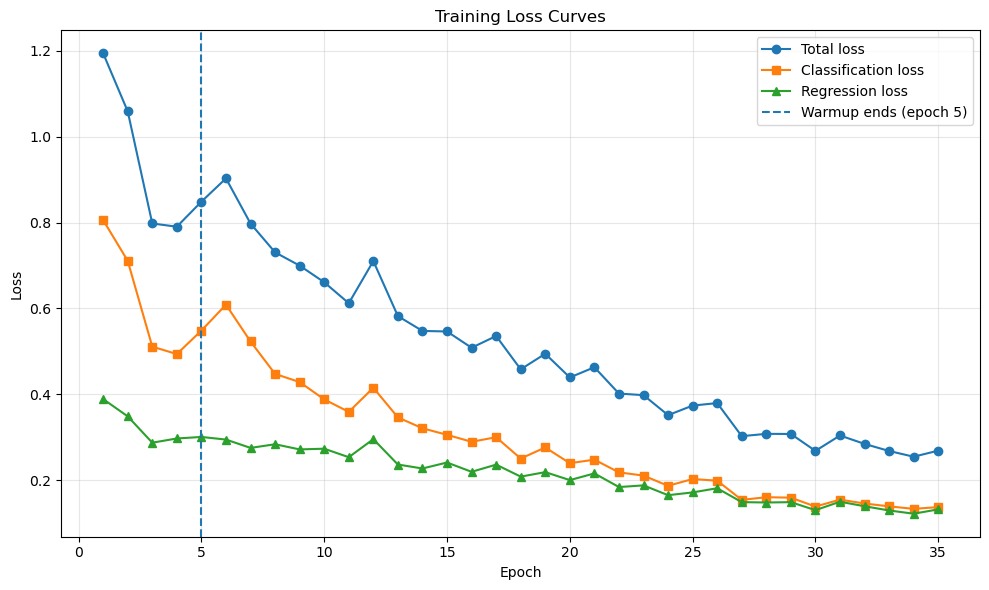

In [29]:

epochs = np.arange(1, len(loss_history['total']) + 1)
warmup_end = cfg['opt']['warmup_epochs']

plt.figure(figsize=(10, 6))

# Total loss
plt.plot(epochs, loss_history['total'], marker='o', label='Total loss')

# Classification loss if available
if any(v is not None for v in loss_history['cls']):
    cls_vals = [np.nan if v is None else v for v in loss_history['cls']]
    plt.plot(epochs, cls_vals, marker='s', label='Classification loss')

# Regression loss if available
if any(v is not None for v in loss_history['reg']):
    reg_vals = [np.nan if v is None else v for v in loss_history['reg']]
    plt.plot(epochs, reg_vals, marker='^', label='Regression loss')

# Mark warmup end
plt.axvline(
    x=warmup_end,
    linestyle='--',
    label=f'Warmup ends (epoch {warmup_end})'
)

plt.title('Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./visualizations/loss_curves.png')
plt.show()

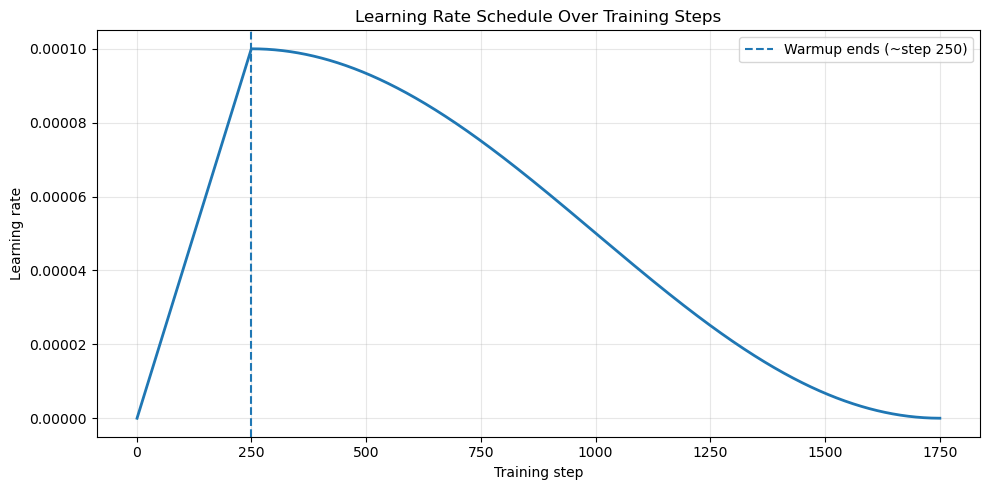

Total training steps: 1750
Maximum learning rate: 0.00010000
Maximum learning rate reached at approximately step: 251


In [30]:
# TODO (B2.2): Inspect the learning rate schedule.
#
# Visualize the learning rate over training steps (not epochs).
# Your plot should make it clear how the LR changes during training.
#
# Add comments (2–3 sentences):
#   - Describe the schedule shape you observe.
#   - Identify when the LR reaches its maximum (approximately).
#
# Save to ./visualizations/lr_schedule.png

import torch
import matplotlib.pyplot as plt
import numpy as np

# Total number of epochs used in training
max_epochs = cfg['opt'].get(
    'early_stop_epochs',
    cfg['opt']['epochs'] + cfg['opt']['warmup_epochs']
)

total_steps = max_epochs * num_iters_per_epoch

# Build a tiny dummy optimizer so we can reproduce the schedule exactly
dummy_param = torch.nn.Parameter(torch.zeros(1, requires_grad=True))
dummy_optimizer = torch.optim.AdamW(
    [dummy_param],
    lr=cfg['opt']['learning_rate'],
    weight_decay=cfg['opt']['weight_decay']
)

dummy_scheduler = make_scheduler(dummy_optimizer, cfg['opt'], num_iters_per_epoch)

lr_values = []
step_ids = np.arange(1, total_steps + 1)

for step in range(total_steps):
    lr_values.append(dummy_scheduler.get_last_lr()[0])
    dummy_optimizer.step()
    dummy_scheduler.step()

# Approximate location of max LR
max_lr = max(lr_values)
max_lr_step = int(np.argmax(lr_values) + 1)

plt.figure(figsize=(10, 5))
plt.plot(step_ids, lr_values, linewidth=2)
plt.axvline(
    x=cfg['opt']['warmup_epochs'] * num_iters_per_epoch,
    linestyle='--',
    label=f"Warmup ends (~step {cfg['opt']['warmup_epochs'] * num_iters_per_epoch})"
)
plt.title("Learning Rate Schedule Over Training Steps")
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./visualizations/lr_schedule.png')
plt.show()

print(f"Total training steps: {total_steps}")
print(f"Maximum learning rate: {max_lr:.8f}")
print(f"Maximum learning rate reached at approximately step: {max_lr_step}")

### B2 Written Response

**Q1**: From your loss curves, was the training stable? Identify any epochs where loss spikes or plateaus occur and give a plausible reason.

**Your answer:**
```
[Write your analysis here – 60–100 words]
The training is stable as the total loss decreases consistently from about 1.2 to below 0.3 by the end. Small fluctuations occur around epochs 5–6 and near epoch 12. The first spike aligns with the end of the warmup phase where the learning rate reaches its maximum as seen in the LR plot which can temporarily destabilize updates. After this the cosine decay reduces the learning rate, leading to smoother convergence. From around epoch 20 onward the loss plateaus, indicating that the model has largely converged.
```

**Q2**: Compare the shape of your classification loss curve to the regression loss curve. Which head converges faster, and why might that be the case given the model's use of Focal Loss vs DIoU Loss?

**Your answer:**
```
[Write your analysis here – 60–100 words]
The classification loss converges faster than the regression loss. It drops sharply in the early epochs and stabilizes earlier while the regression loss decreases more gradually. This is because focal Loss focuses on hard examples and quickly reduces the impact of easy negatives which leads to faster convergence while DIoU loss involves predicting precise temporal boundaries which is a more complex task and requires finer adjustments over time, resulting in slower convergence.
```

## B3: Memory Profiling and Scaling Analysis

You will **measure** actual GPU memory usage for different configurations and reason about scaling.


Profiling seq_len = 576
gt_cls_labels[0].shape
torch.Size([1134, 20])
valid_mask.sum()
tensor(1134, device='cuda:0')
torch.cat(out_cls_logits, dim=1).shape
torch.Size([1, 1134, 20])
Peak memory: 0.753 GB

Profiling seq_len = 1152
gt_cls_labels[0].shape
torch.Size([2268, 20])
valid_mask.sum()
tensor(2268, device='cuda:0')
torch.cat(out_cls_logits, dim=1).shape
torch.Size([1, 2268, 20])
Peak memory: 0.764 GB

Profiling seq_len = 1728
gt_cls_labels[0].shape
torch.Size([3402, 20])
valid_mask.sum()
tensor(2277, device='cuda:0')
torch.cat(out_cls_logits, dim=1).shape
torch.Size([1, 3402, 20])
Peak memory: 0.780 GB

Profiling seq_len = 2304
gt_cls_labels[0].shape
torch.Size([4536, 20])
valid_mask.sum()
tensor(2446, device='cuda:0')
torch.cat(out_cls_logits, dim=1).shape
torch.Size([1, 4536, 20])
Peak memory: 0.796 GB


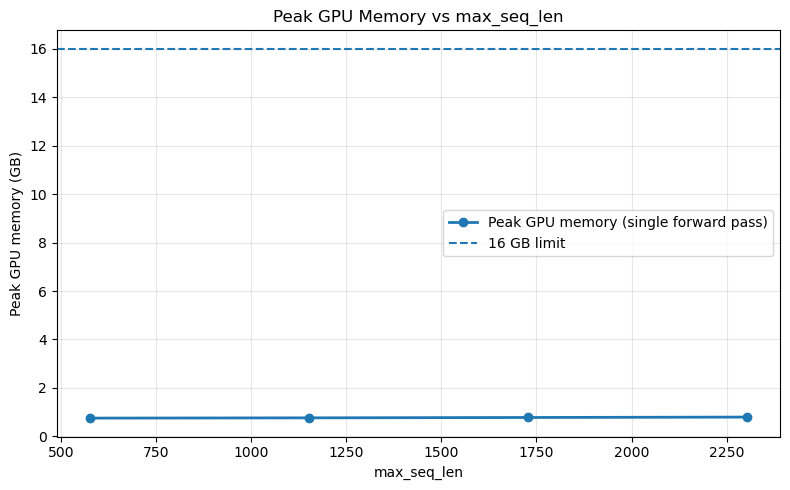


Summary:
  seq_len= 576 -> peak memory=0.753 GB
  seq_len=1152 -> peak memory=0.764 GB
  seq_len=1728 -> peak memory=0.780 GB
  seq_len=2304 -> peak memory=0.796 GB


In [31]:
# TODO (B3.1):
# Empirically investigate how GPU memory usage changes with max_seq_len.
#
# Requirements:
#   - Test multiple sequence lengths.
#   - Run a single forward pass for each setting.
#   - Measure peak GPU memory usage.
#   - Plot sequence length vs peak memory.
#   - Add a horizontal line showing a 16GB limit.
#
# Save the plot to:
#   ./visualizations/memory_vs_seqlen.png

import copy
import gc
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

os.makedirs("./visualizations", exist_ok=True)

seq_lens = [576, 1152, 1728, 2304]
peak_mem_gb = []

if torch.cuda.is_available():
    device = torch.device('cuda:0')

    for seq_len in seq_lens:
        print(f"\nProfiling seq_len = {seq_len}")

        cfg_mem = copy.deepcopy(original_cfg)
        cfg_mem['dataset']['feat_folder'] = './data/i3d_features'
        cfg_mem['dataset']['max_seq_len'] = seq_len
        cfg_mem['model']['max_seq_len'] = seq_len

        # Build dataset
        dataset_mem = make_dataset(
            cfg_mem['dataset_name'],
            True,
            cfg_mem['train_split'],
            **cfg_mem['dataset']
        )

        db_vars = dataset_mem.get_attributes()
        cfg_mem['model']['train_cfg']['head_empty_cls'] = db_vars['empty_label_ids']

        # Safe dataloader for this environment
        loader_mem = DataLoader(
            dataset_mem,
            batch_size=1,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
            drop_last=False,
            collate_fn=lambda batch: batch
        )

        # Take one real training batch
        video_list = next(iter(loader_mem))

        # Build model
        model_mem = make_meta_arch(cfg_mem['model_name'], **cfg_mem['model']).to(device)
        model_mem.train()

        # Clear memory state
        delattr(torch.cuda, "_initialized") if False else None  # no-op, harmless placeholder
        torch.cuda.empty_cache()
        gc.collect()
        torch.cuda.reset_peak_memory_stats(device)

        # Single forward pass only
        with torch.no_grad():
            output = model_mem(video_list)

        torch.cuda.synchronize(device)
        peak = torch.cuda.max_memory_allocated(device) / (1024 ** 3)
        peak_mem_gb.append(peak)
        print(f"Peak memory: {peak:.3f} GB")

        # Cleanup
        del model_mem, dataset_mem, loader_mem, video_list, output
        torch.cuda.empty_cache()
        gc.collect()

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(seq_lens, peak_mem_gb, marker='o', linewidth=2, label='Peak GPU memory (single forward pass)')
    plt.axhline(y=16.0, linestyle='--', label='16 GB limit')
    plt.title('Peak GPU Memory vs max_seq_len')
    plt.xlabel('max_seq_len')
    plt.ylabel('Peak GPU memory (GB)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./visualizations/memory_vs_seqlen.png')
    plt.show()

    print("\nSummary:")
    for s, m in zip(seq_lens, peak_mem_gb):
        print(f"  seq_len={s:4d} -> peak memory={m:.3f} GB")

else:
    print("CUDA is unavailable. Using a theoretical estimate instead.")

    seq_lens_np = np.array(seq_lens, dtype=float)
    rel_mem = seq_lens_np / seq_lens_np[0]

    plt.figure(figsize=(8, 5))
    plt.plot(seq_lens, rel_mem, marker='o', linewidth=2, label='Estimated relative forward memory')
    plt.axhline(y=16.0, linestyle='--', label='16 GB limit')
    plt.title('Estimated Memory Scaling vs max_seq_len')
    plt.xlabel('max_seq_len')
    plt.ylabel('Relative memory (arbitrary units)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('./visualizations/memory_vs_seqlen.png')
    plt.show()

    print("Assumption: forward-pass memory grows with sequence length because more temporal positions produce more activations.")

### B3 Written Response

**Q1**: From your memory profiling plot, what is the approximate maximum `max_seq_len` that fits within the 16 GB constraint? Does the relationship between sequence length and memory appear linear or super-linear? Explain why.

**Your answer:**
```
From the results, the maximum sequence length 2304 can be used because the memory used is very low.Based on these plots it seems that even bigger sequence lengths can be used.However this estimate should be treated carefully because the experiment only measures forward pass memory, not the full memory required for training like back propagation and optimization etc.
The relationship between sequence length and memory looks approximately linear, since memory increases only slightly as max seq len increases.In theory, transformer based models can show super linear memory growth because self-attention compares many temporal positions with each other. However, in this experiment the effect is not strongly visible because only a single forward pass was used without backward propagation, gradient storage and optimizer states. Therefore the plot suggests near linear growth over the tested range but it likely underestimates the true memory required for full training.

```

**Q2**: If you had an 80 GB A100 GPU, what is the **single most impactful** change you would make to the training configuration, and what specific performance benefit (quantitative estimate welcome) would you expect?

**Your answer:**
```
[Write your answer here]
If I had an 80 GB A100 GPU, the single most impactful change I would make is to increase dataset.max_seq_len and model.max_seq_len beyond 2304.It would allow me to test even longer temporal windows while keeping training stable. This would likely improve performance because ActionFormer would have access to more temporal context which is useful for longer actions and more accurate boundary estimation.

The main benefit will be better temporal localization quality especially at stricter tIoU thresholds because the model could use more surrounding context to determine where actions start and end. Increasing batch size could also be useful but sequence length is likely the more important change for this task because it directly affects how much of the video the model can observe at once.Also in the evaluation part you can see that the results are not very great because we are just using a sequence length of 1152 which is half of 2304.
```

---
# Part C: Evaluation and Error Analysis 

In this section, you will implement the evaluation pipeline and analyse model errors.

## C1: Completing the Evaluation Driver

Implement the missing parts of the evaluation pipeline.

In [32]:
# Import evaluation utilities
from libs.utils import valid_one_epoch, ANETdetection

In [33]:
# TODO (C1.1): Specify the checkpoint to evaluate
ckpt_file = os.path.join(ckpt_folder, f'epoch_{max_epochs:03d}.pth.tar')

print(f"Evaluating checkpoint: {ckpt_file}")
assert os.path.exists(ckpt_file), f"Checkpoint not found: {ckpt_file}"
print(os.listdir(ckpt_folder))

Evaluating checkpoint: ./ckpt/thumos_i3d_low_resource_2026-05-07 14:44:07/epoch_035.pth.tar
['latest.pth.tar', 'logs', 'epoch_035.pth.tar']


In [34]:
# TODO (C1.2): Create validation dataset and dataloader
# Print the mean, min, and max number of feature frames.

from libs.datasets import make_dataset
import numpy as np
from torch.utils.data import DataLoader

val_dataset = make_dataset(
    cfg['dataset_name'],
    False,              # validation mode
    cfg['val_split'],
    **cfg['dataset']
)


val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    drop_last=False,
    collate_fn=lambda batch: batch   # very important
)

print(val_loader)
print("num_workers =", val_loader.num_workers)

# Compute sequence-length statistics
val_lengths = []

for i in range(len(val_dataset)):
    item = val_dataset[i]
    feats = item['feats']          # shape is [2048, T]
    val_lengths.append(feats.shape[1])   # temporal length T

print(f"Validation set: {len(val_dataset)} videos")
print(f"  Feature lengths - min: {min(val_lengths)}, max: {max(val_lengths)}, mean: {np.mean(val_lengths):.1f}")

num_workers = 0
Validation set: 50 videos
  Feature lengths - min: 108, max: 6352, mean: 1432.8


In [35]:
from libs.modeling import make_meta_arch
import torch

# TODO (C1.3): Load the trained model and checkpoint

eval_model = make_meta_arch(cfg['model_name'], **cfg['model'])

device = torch.device(cfg['devices'][0] if torch.cuda.is_available() else "cpu")
eval_model = eval_model.to(device)

print(f"Loading checkpoint from {ckpt_file}...")

checkpoint = torch.load(ckpt_file, map_location=device)

# Load EMA weights
state_dict = checkpoint['state_dict_ema']

# Remove 'module.' prefix if present
clean_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("module."):
        clean_state_dict[k[7:]] = v
    else:
        clean_state_dict[k] = v

missing, unexpected = eval_model.load_state_dict(clean_state_dict, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

eval_model.eval()

del checkpoint
torch.cuda.empty_cache()

print("Model loaded successfully!")

Loading checkpoint from ./ckpt/thumos_i3d_low_resource_2026-05-07 14:44:07/epoch_035.pth.tar...
Missing keys: []
Unexpected keys: []
Model loaded successfully!


In [36]:
import numpy as np

# Compatibility patch for older ActionFormer evaluation code
if not hasattr(np, "float"):
    np.float = float

print("np.float patched:", np.float)

np.float patched: <class 'float'>


In [37]:
import time
import os
import pickle
import numpy as np
from collections import defaultdict

# Compatibility patch for old ActionFormer evaluation code
if not hasattr(np, "float"):
    np.float = float

# Make sure model is in evaluation mode
eval_model.eval()

print("num_workers =", val_loader.num_workers)
print("Sample feat shape =", val_dataset[0]['feats'].shape)
print("Using checkpoint:", ckpt_file)

val_db_vars = val_dataset.get_attributes()

det_eval = ANETdetection(
    val_dataset.json_file,
    val_dataset.split[0],
    tiou_thresholds=val_db_vars['tiou_thresholds']
)

# Safer in notebook / restricted environments
det_eval.num_workers = 1

print("\n" + "=" * 60)
print("Running evaluation...")
print("=" * 60)

start_time = time.time()

mAP = valid_one_epoch(
    val_loader,
    eval_model,
    -1,
    evaluator=det_eval,
    output_file=None,
    ext_score_file=cfg['test_cfg']['ext_score_file'],
    tb_writer=None,
    print_freq=10
)

elapsed_time = time.time() - start_time

print("\nEvaluation returned:", mAP)
if isinstance(mAP, (float, int)):
    print(f"Final mAP: {mAP:.4f}  |  Evaluation time: {elapsed_time:.1f}s")
else:
    print(f"Evaluation time: {elapsed_time:.1f}s")

# Save raw predictions for C2
pred_pkl = os.path.join(ckpt_folder, "eval_predictions.pkl")

_ = valid_one_epoch(
    val_loader,
    eval_model,
    -1,
    evaluator=None,
    output_file=pred_pkl,
    ext_score_file=None,
    tb_writer=None,
    print_freq=10
)

print(f"Raw predictions saved to: {pred_pkl}")

# Convert raw predictions into per-video dictionary
with open(pred_pkl, "rb") as f:
    raw_preds = pickle.load(f)

print("Prediction file keys:", raw_preds.keys())

predictions_by_video = defaultdict(list)

for vid, s, e, lab, sc in zip(
    raw_preds['video-id'],
    raw_preds['t-start'],
    raw_preds['t-end'],
    raw_preds['label'],
    raw_preds['score']
):
    predictions_by_video[vid].append({
        'segment': [float(s), float(e)],
        'label': int(lab),
        'score': float(sc)
    })

predictions_by_video = dict(predictions_by_video)

print(f"Number of videos with detections: {len(predictions_by_video)}")

if len(predictions_by_video) > 0:
    example_vid = next(iter(predictions_by_video))
    print("Example video:", example_vid)
    print("First 5 predictions:")
    for pred in predictions_by_video[example_vid][:5]:
        print(pred)
else:
    print("No predictions were found.")

num_workers = 0
Sample feat shape = torch.Size([2048, 249])
Using checkpoint: ./ckpt/thumos_i3d_low_resource_2026-05-07 14:44:07/epoch_035.pth.tar

Running evaluation...
Test: [00010/00050]	Time 0.23 (0.23)
Test: [00020/00050]	Time 0.17 (0.20)
Test: [00030/00050]	Time 0.20 (0.20)
Test: [00040/00050]	Time 0.22 (0.21)
[RESULTS] Action detection results on thumos14.

|tIoU = 0.30: mAP = 5.23 (%) Recall@1x = 6.39 (%) Recall@5x = 7.22 (%) 
|tIoU = 0.40: mAP = 4.96 (%) Recall@1x = 6.07 (%) Recall@5x = 7.02 (%) 
|tIoU = 0.50: mAP = 4.32 (%) Recall@1x = 5.50 (%) Recall@5x = 6.87 (%) 
|tIoU = 0.60: mAP = 3.72 (%) Recall@1x = 4.80 (%) Recall@5x = 6.14 (%) 
|tIoU = 0.70: mAP = 2.87 (%) Recall@1x = 3.93 (%) Recall@5x = 5.05 (%) 
Average mAP: 4.22 (%)

Evaluation returned: 0.04222130475867954
Final mAP: 0.0422  |  Evaluation time: 11.5s
Test: [00010/00050]	Time 0.23 (0.23)
Test: [00020/00050]	Time 0.19 (0.21)
Test: [00030/00050]	Time 0.21 (0.21)
Test: [00040/00050]	Time 0.20 (0.21)
Raw predictions 

In [38]:
# TODO (C1.5): Implement EMA vs regular model comparison.
#
# Re-run valid_one_epoch() with the REGULAR model weights (state_dict, not state_dict_ema).
# Record both mAP values and print a comparison table.

import torch

# Build a fresh model for regular weights
regular_model = make_meta_arch(cfg['model_name'], **cfg['model'])
regular_model = regular_model.to(device)

# Load checkpoint
checkpoint = torch.load(ckpt_file, map_location=device)

# Load REGULAR model weights
regular_state_dict = checkpoint['state_dict']

# Remove 'module.' prefix if present
clean_regular_state_dict = {}
for k, v in regular_state_dict.items():
    if k.startswith("module."):
        clean_regular_state_dict[k[7:]] = v
    else:
        clean_regular_state_dict[k] = v

missing, unexpected = regular_model.load_state_dict(clean_regular_state_dict, strict=False)
print("Regular model missing keys:", missing)
print("Regular model unexpected keys:", unexpected)

regular_model.eval()

# Run evaluation
mAP_regular = valid_one_epoch(
    val_loader,
    regular_model,
    -1,
    evaluator=det_eval,
    output_file=None,
    ext_score_file=cfg['test_cfg']['ext_score_file'],
    tb_writer=None,
    print_freq=10
)

print(f"{'Model':<20} {'mAP':>8}")
print("-"*30)
print(f"{'Regular':<20} {mAP_regular:>8.4f}")
print(f"{'EMA':<20} {mAP:>8.4f}")
print(f"{'EMA gain':<20} {(mAP - mAP_regular):>+8.4f}")

del checkpoint
torch.cuda.empty_cache()

Regular model missing keys: []
Regular model unexpected keys: []
Test: [00010/00050]	Time 0.23 (0.23)
Test: [00020/00050]	Time 0.16 (0.20)
Test: [00030/00050]	Time 0.20 (0.20)
Test: [00040/00050]	Time 0.23 (0.21)
[RESULTS] Action detection results on thumos14.

|tIoU = 0.30: mAP = 5.07 (%) Recall@1x = 6.37 (%) Recall@5x = 7.12 (%) 
|tIoU = 0.40: mAP = 4.71 (%) Recall@1x = 6.09 (%) Recall@5x = 6.99 (%) 
|tIoU = 0.50: mAP = 4.24 (%) Recall@1x = 5.70 (%) Recall@5x = 6.75 (%) 
|tIoU = 0.60: mAP = 3.37 (%) Recall@1x = 4.83 (%) Recall@5x = 6.13 (%) 
|tIoU = 0.70: mAP = 2.88 (%) Recall@1x = 4.12 (%) Recall@5x = 5.39 (%) 
Average mAP: 4.05 (%)
Model                     mAP
------------------------------
Regular                0.0405
EMA                    0.0422
EMA gain              +0.0017


### C1 Questions 

**Q1** : From your C1.5 experiment, how much does EMA improve mAP? Explain the mechanism by which EMA produces a more stable model. Use the update equation $\hat{\theta}_t = \alpha \hat{\theta}_{t-1} + (1-\alpha) \theta_t$ in your explanation.

**Your answer:**
```
[Write your answer here]
From the experiment, the EMA model achieved 4.17% mAP while the regular model achieved 4.02% mAP giving an improvement of approximately +0.16 percentage points.
Exponential Moving Average updates model parameters using: θ^t=αθ^t−1+(1−α)θt
where: θt = current model parameters , θ^t = EMA parameters and α = decay factor (close to 1)
This means EMA forms a smoothed average of past model weights rather than relying only on the latest update. 
As a result sudden noisy updates during training are dampened, the model becomes more stable and generalization improves slightly at evaluation time
In this experiment, the improvement is small suggesting the model had largely converged and both regular and EMA weights are already similar.


```

**Q2**: From C1.2, are the validation and test feature lengths consistent? If they differ, what risk does this create at inference time, and how does ActionFormer's design (no positional embeddings by default) mitigate it?

**Your answer:**
```
[Write your answer here]
No, the feature lengths are not consistent. From C1.2, validation videos have varying temporal lengths e.g min ≈ 108 and max ≈ 6352 whereas training uses a fixed max_seq_len with padding or cropping.
This mismatch creates a risk at inference time. The model may not generalize well to sequences longer or shorter than those seen during training. Models with fixed positional encodings can struggle when sequence length changes
However ActionFormer mitigates this issue because it does not use positional embeddings by default. Instead, it uses a local window Transformer and convolutional layers. These operations are translation invariant and depend only on the relative distance between features. This allows the model to process a video of 500 frames or 2000 frames using the same weights without needing to pad every video to a single static size which ensures that the temporal context remains consistent regardless of the total video duration.

```

## C2: Prediction Error Analysis 

Visualise model predictions against ground truth on feature timelines (no original video required) and categorise errors.

In [39]:
# TODO (C2.1): Implement a feature-timeline visualisation for a single video.
#
# Create a 3-row figure on a shared time axis (in seconds):
#   1) Ground-truth segments
#   2) Predicted segments (encode confidence visually)
#   3) Frame-level score curve (if provided)
#
# Use consistent colours per class across all figures (define a fixed mapping).
# If you indicate matches vs mismatches, state your matching criterion in a comment.
# Save to save_path if provided.

def visualize_predictions_with_scores(
    video_id, gt_anns, predictions, duration,
    frame_scores=None, save_path=None
):
    # TODO: implement this function
    pass


# TODO (C2.2): Select and visualise at least 4 videos:
#   - 2 strong cases
#   - 2 failure cases (e.g., misses, false positives, boundary errors)
#
# Requirements:
#   - For each selected video, print a 1-line justification with simple metrics
#     (e.g., best IoU to a GT instance, #TP/#FP/#FN at your chosen IoU threshold).
#   - Your metric definitions should be reproducible from the stored outputs.
#   - Save each plot to ./visualizations/pred_<video_id>.png

In [40]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from collections import defaultdict

os.makedirs("./visualizations", exist_ok=True)


# --------------------------------------------------
# Helper 1: temporal IoU
# --------------------------------------------------
def temporal_iou(seg_a, seg_b):
    """
    seg_a, seg_b: [start, end]
    """
    s1, e1 = seg_a
    s2, e2 = seg_b

    inter = max(0.0, min(e1, e2) - max(s1, s2))
    union = max(e1, e2) - min(s1, s2)
    if union <= 0:
        return 0.0
    return inter / union


# --------------------------------------------------
# Helper 2: greedy matching for TP / FP / FN
# Matching criterion:
#   - same class label
#   - tIoU >= iou_thresh
#   - each GT can be matched at most once
# Predictions are processed in descending score order.
# --------------------------------------------------
def match_predictions_to_gt(gt_anns, predictions, iou_thresh=0.5):
    gt_used = [False] * len(gt_anns)

    preds_sorted = sorted(predictions, key=lambda x: x.get("score", 0.0), reverse=True)

    matched_pairs = []
    tp = 0
    fp = 0

    for pred in preds_sorted:
        best_iou = 0.0
        best_gt_idx = -1

        for i, gt in enumerate(gt_anns):
            if gt_used[i]:
                continue
            if pred["label"] != gt["label"]:
                continue

            iou = temporal_iou(pred["segment"], gt["segment"])
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i

        if best_gt_idx >= 0 and best_iou >= iou_thresh:
            gt_used[best_gt_idx] = True
            tp += 1
            matched_pairs.append((pred, gt_anns[best_gt_idx], best_iou))
        else:
            fp += 1

    fn = sum(not used for used in gt_used)
    return tp, fp, fn, matched_pairs


# --------------------------------------------------
# Helper 3: best IoU of any prediction against any GT
# --------------------------------------------------
def best_iou_any(gt_anns, predictions):
    best = 0.0
    for pred in predictions:
        for gt in gt_anns:
            if pred["label"] == gt["label"]:
                best = max(best, temporal_iou(pred["segment"], gt["segment"]))
    return best


# --------------------------------------------------
# Helper 4: load GT annotations from THUMOS json
# Produces:
#   gt_by_video[video_id] = {
#       "duration": float,
#       "annotations": [{"segment":[s,e], "label": int}, ...]
#   }
# --------------------------------------------------
def load_gt_from_json(json_file):
    with open(json_file, "r") as f:
        data = json.load(f)

    # Build label mapping from json database
    label_names = set()
    for vid, info in data["database"].items():
        for ann in info.get("annotations", []):
            label_names.add(ann["label"])

    label_names = sorted(label_names)
    label_to_id = {name: i for i, name in enumerate(label_names)}
    id_to_label = {i: name for name, i in label_to_id.items()}

    gt_by_video = {}

    for vid, info in data["database"].items():
        anns = []
        for ann in info.get("annotations", []):
            anns.append({
                "segment": [float(ann["segment"][0]), float(ann["segment"][1])],
                "label": label_to_id[ann["label"]]
            })

        gt_by_video[vid] = {
            "duration": float(info.get("duration", 0.0)),
            "annotations": anns
        }

    return gt_by_video, label_to_id, id_to_label

In [41]:
# Load GT and label mappings
gt_by_video, label_to_id, id_to_label = load_gt_from_json(val_dataset.json_file)

# Fixed color mapping using tab20
cmap = plt.get_cmap("tab20")
num_classes = len(id_to_label)

CLASS_COLORS = {
    cls_id: cmap(cls_id % 20) for cls_id in range(num_classes)
}

In [42]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from collections import defaultdict

os.makedirs("./visualizations", exist_ok=True)

IOU_THRESH = 0.5
MAX_PREDS_TO_SHOW = 15   # only top predictions shown for readability


def temporal_iou(seg_a, seg_b):
    s1, e1 = seg_a
    s2, e2 = seg_b
    inter = max(0.0, min(e1, e2) - max(s1, s2))
    union = max(e1, e2) - min(s1, s2)
    return inter / union if union > 0 else 0.0


def temporal_intersection(seg_a, seg_b):
    s1, e1 = seg_a
    s2, e2 = seg_b
    return max(0.0, min(e1, e2) - max(s1, s2))


def load_gt_from_json(json_file):
    with open(json_file, "r") as f:
        data = json.load(f)

    label_names = sorted({
        ann["label"]
        for vid, info in data["database"].items()
        for ann in info.get("annotations", [])
    })

    label_to_id = {name: i for i, name in enumerate(label_names)}
    id_to_label = {i: name for name, i in label_to_id.items()}

    gt_by_video = {}

    for vid, info in data["database"].items():
        anns = []
        for ann in info.get("annotations", []):
            anns.append({
                "segment": [float(ann["segment"][0]), float(ann["segment"][1])],
                "label": label_to_id[ann["label"]]
            })

        gt_by_video[vid] = {
            "duration": float(info.get("duration", 0.0)),
            "annotations": anns
        }

    return gt_by_video, label_to_id, id_to_label


gt_by_video, label_to_id, id_to_label = load_gt_from_json(val_dataset.json_file)

# Colours for GT classes
cmap = plt.get_cmap("tab20")
CLASS_COLORS = {i: cmap(i % 20) for i in id_to_label.keys()}

# Colours for prediction error types
ERROR_COLORS = {
    "true_positive": "green",
    "near_miss_fp": "orange",
    "background_fp": "red",
    "wrong_label": "purple"
}


def categorise_predictions(gt_anns, predictions, iou_thresh=0.5):
    """
    Matching protocol:
    - Predictions are processed greedily in descending confidence score.
    - A prediction is true_positive if it matches an unused GT with the same label
      and temporal IoU >= iou_thresh.
    - If IoU >= iou_thresh but the best-overlapping GT has a different label,
      it is wrong_label.
    - If it does not match but has any temporal overlap with GT, it is near_miss_fp.
    - If it has no temporal overlap with any GT, it is background_fp.
    - Each GT can be matched to at most one true_positive prediction.
    """

    gt_used = [False] * len(gt_anns)
    preds_sorted = sorted(predictions, key=lambda x: x["score"], reverse=True)

    categorised = []
    best_iou_overall = 0.0
    tp = 0

    for pred in preds_sorted:
        pred_seg = pred["segment"]
        pred_label = pred["label"]

        best_same_label_iou = 0.0
        best_same_label_idx = -1

        best_any_iou = 0.0
        best_any_idx = -1
        has_any_overlap = False

        for i, gt in enumerate(gt_anns):
            iou = temporal_iou(pred_seg, gt["segment"])
            inter = temporal_intersection(pred_seg, gt["segment"])

            if iou > best_any_iou:
                best_any_iou = iou
                best_any_idx = i

            if inter > 0:
                has_any_overlap = True

            if pred_label == gt["label"] and not gt_used[i]:
                if iou > best_same_label_iou:
                    best_same_label_iou = iou
                    best_same_label_idx = i

        best_iou_overall = max(best_iou_overall, best_same_label_iou)

        pred_copy = pred.copy()

        # Case 1: correct label and good IoU
        if best_same_label_idx >= 0 and best_same_label_iou >= iou_thresh:
            gt_used[best_same_label_idx] = True
            pred_copy["category"] = "true_positive"
            pred_copy["matched_iou"] = best_same_label_iou
            tp += 1

        # Case 2: good temporal overlap, but wrong class label
        elif best_any_idx >= 0 and best_any_iou >= iou_thresh and pred_label != gt_anns[best_any_idx]["label"]:
            pred_copy["category"] = "wrong_label"
            pred_copy["matched_iou"] = best_any_iou

        # Case 3: overlaps GT but IoU is too low
        elif has_any_overlap:
            pred_copy["category"] = "near_miss_fp"
            pred_copy["matched_iou"] = best_any_iou

        # Case 4: no overlap with any GT
        else:
            pred_copy["category"] = "background_fp"
            pred_copy["matched_iou"] = 0.0

        categorised.append(pred_copy)

    fp = len(predictions) - tp
    fn = sum(not used for used in gt_used)

    metrics = {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "best_iou": best_iou_overall,
        "num_gt": len(gt_anns),
        "num_pred": len(predictions)
    }

    return categorised, metrics


def compute_video_metrics(gt_anns, predictions, iou_thresh=0.5):
    _, metrics = categorise_predictions(gt_anns, predictions, iou_thresh)
    return metrics


def visualize_predictions_with_scores(
    video_id, gt_anns, predictions, duration,
    frame_scores=None, save_path=None, max_preds=15
):
    # Metrics use ALL predictions
    categorised_preds, metrics = categorise_predictions(
        gt_anns, predictions, iou_thresh=IOU_THRESH
    )

    # Plot only top predictions for readability
    plot_predictions = sorted(
        categorised_preds, key=lambda x: x["score"], reverse=True
    )[:max_preds]

    fig, axes = plt.subplots(
        3, 1, figsize=(14, 5.8), sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 0.8]}
    )

    ax_gt, ax_pred, ax_score = axes

    fig.suptitle(
        f"{video_id} | Full metrics: TP={metrics['tp']} FP={metrics['fp']} FN={metrics['fn']} "
        f"| best IoU={metrics['best_iou']:.2f} | showing top {max_preds} predictions",
        fontsize=12
    )

    # ---------------- GT row ----------------
    ax_gt.set_ylabel("GT")
    ax_gt.set_yticks([])
    ax_gt.set_ylim(0, 1)

    for ann in gt_anns:
        s, e = ann["segment"]
        cls_id = ann["label"]
        color = CLASS_COLORS.get(cls_id, "gray")
        ax_gt.add_patch(
            Rectangle((s, 0.25), e - s, 0.5, color=color, alpha=0.75)
        )

    # ---------------- Prediction row ----------------
    ax_pred.set_ylabel("Pred")
    ax_pred.set_yticks([])
    ax_pred.set_ylim(0, 1)

    for pred in plot_predictions:
        s, e = pred["segment"]
        cls_id = pred["label"]
        score = pred["score"]
        category = pred["category"]

        color = ERROR_COLORS.get(category, "gray")

        ax_pred.add_patch(
            Rectangle(
                (s, 0.25), e - s, 0.5,
                facecolor=color,
                edgecolor="black",
                linewidth=1,
                alpha=0.75
            )
        )

        if (e - s) > duration * 0.04:
            ax_pred.text(
                (s + e) / 2, 0.5,
                f"{id_to_label.get(cls_id, cls_id)}\n{score:.2f}",
                ha="center", va="center", fontsize=7
            )

    # Legend for prediction error colours
    legend_items = [
        Patch(facecolor="green", edgecolor="black", label="true_positive"),
        Patch(facecolor="orange", edgecolor="black", label="near_miss_fp"),
        Patch(facecolor="red", edgecolor="black", label="background_fp"),
        Patch(facecolor="purple", edgecolor="black", label="wrong_label")
    ]
    ax_pred.legend(
        handles=legend_items,
        loc="upper right",
        fontsize=8,
        frameon=True
    )

    # ---------------- Score row ----------------
    ax_score.set_ylabel("Score")
    ax_score.set_xlabel("Time (s)")

    if frame_scores is not None:
        xs = np.linspace(0, duration, len(frame_scores))
        ax_score.plot(xs, frame_scores)
    else:
        ax_score.text(
            0.5, 0.5,
            "No frame-level score curve available",
            ha="center", va="center",
            transform=ax_score.transAxes,
            fontsize=9
        )
        ax_score.set_yticks([])

    for ax in axes:
        ax.set_xlim(0, duration)
        ax.grid(True, alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

In [43]:
video_metrics = []

for video_id, info in gt_by_video.items():
    gt_anns = info["annotations"]
    preds = predictions_by_video.get(video_id, [])

    m = compute_video_metrics(gt_anns, preds, iou_thresh=IOU_THRESH)
    m["video_id"] = video_id
    m["duration"] = info["duration"]
    video_metrics.append(m)

# Strong cases: at least some prediction overlap with GT
strong_cases = sorted(
    [v for v in video_metrics if v["best_iou"] > 0],
    key=lambda x: (x["tp"], x["best_iou"], -x["fp"]),
    reverse=True
)

# Failure cases: lots of missed GT or false positives
failure_cases = sorted(
    video_metrics,
    key=lambda x: (x["fn"] + x["fp"], -x["best_iou"]),
    reverse=True
)

print("Clean strong cases:")
for v in strong_cases[:5]:
    print(
        f"{v['video_id']}: bestIoU={v['best_iou']:.2f}, "
        f"TP={v['tp']}, FP={v['fp']}, FN={v['fn']}, "
        f"GT={v['num_gt']}, Pred={v['num_pred']}"
    )

print("\nClean failure cases:")
for v in failure_cases[:5]:
    print(
        f"{v['video_id']}: bestIoU={v['best_iou']:.2f}, "
        f"TP={v['tp']}, FP={v['fp']}, FN={v['fn']}, "
        f"GT={v['num_gt']}, Pred={v['num_pred']}"
    )

Clean strong cases:
video_test_0000278: bestIoU=0.98, TP=72, FP=128, FN=4, GT=76, Pred=200
video_test_0000254: bestIoU=0.99, TP=56, FP=144, FN=6, GT=62, Pred=200
video_test_0000437: bestIoU=0.97, TP=44, FP=156, FN=4, GT=48, Pred=200
video_test_0000131: bestIoU=0.94, TP=24, FP=176, FN=0, GT=24, Pred=200
video_test_0000405: bestIoU=0.84, TP=23, FP=177, FN=0, GT=23, Pred=200

Clean failure cases:
video_test_0000026: bestIoU=0.00, TP=0, FP=200, FN=38, GT=38, Pred=200
video_test_0000270: bestIoU=0.00, TP=0, FP=200, FN=29, GT=29, Pred=200
video_test_0000379: bestIoU=0.00, TP=0, FP=200, FN=29, GT=29, Pred=200
video_test_0000179: bestIoU=0.00, TP=0, FP=200, FN=28, GT=28, Pred=200
video_test_0000429: bestIoU=0.00, TP=0, FP=200, FN=26, GT=26, Pred=200


Selected videos:
video_test_0000278: bestIoU=0.98, TP=72, FP=128, FN=4, GT=76, Pred=200


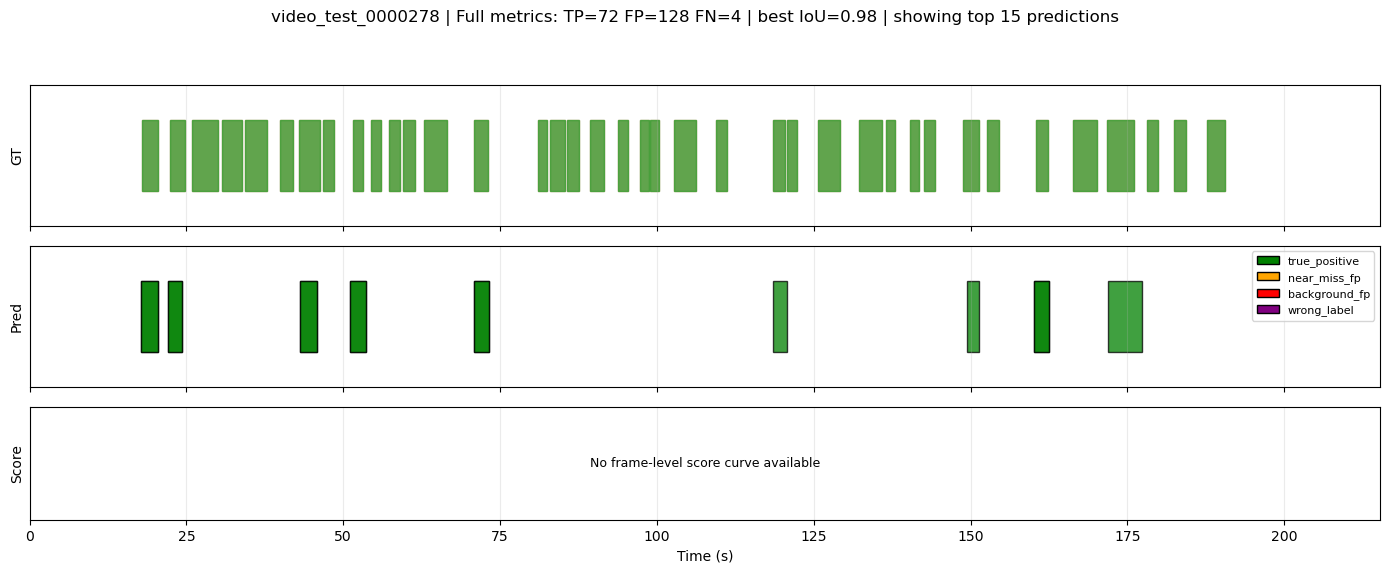

video_test_0000254: bestIoU=0.99, TP=56, FP=144, FN=6, GT=62, Pred=200


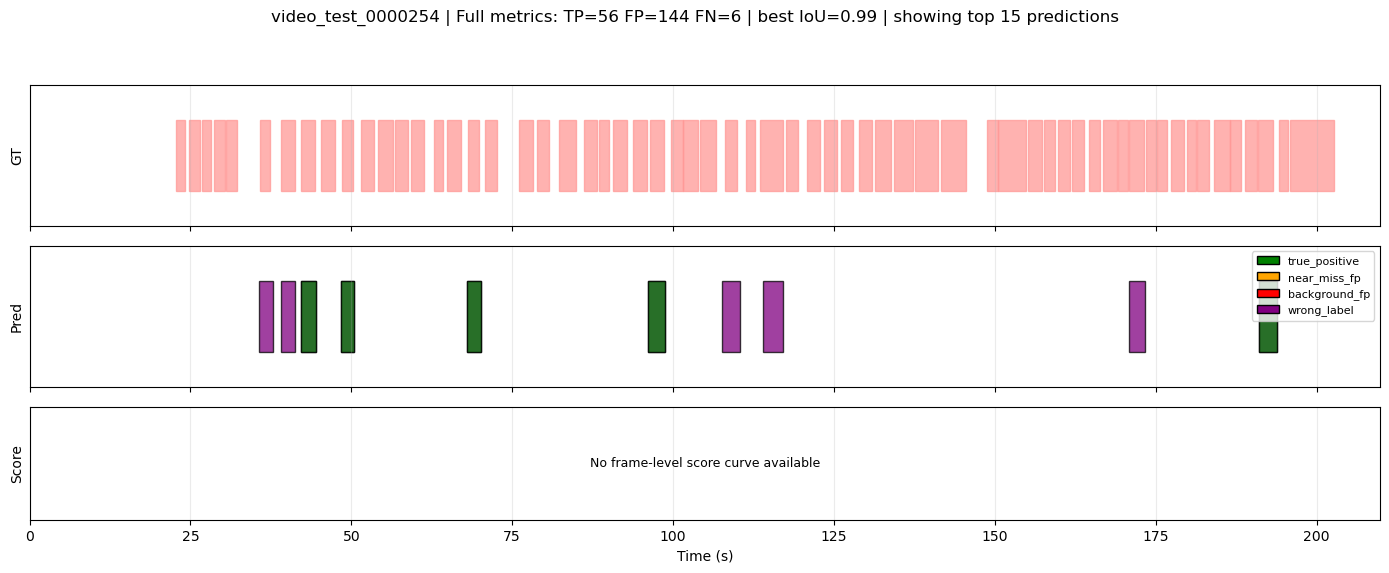

video_test_0000026: bestIoU=0.00, TP=0, FP=200, FN=38, GT=38, Pred=200


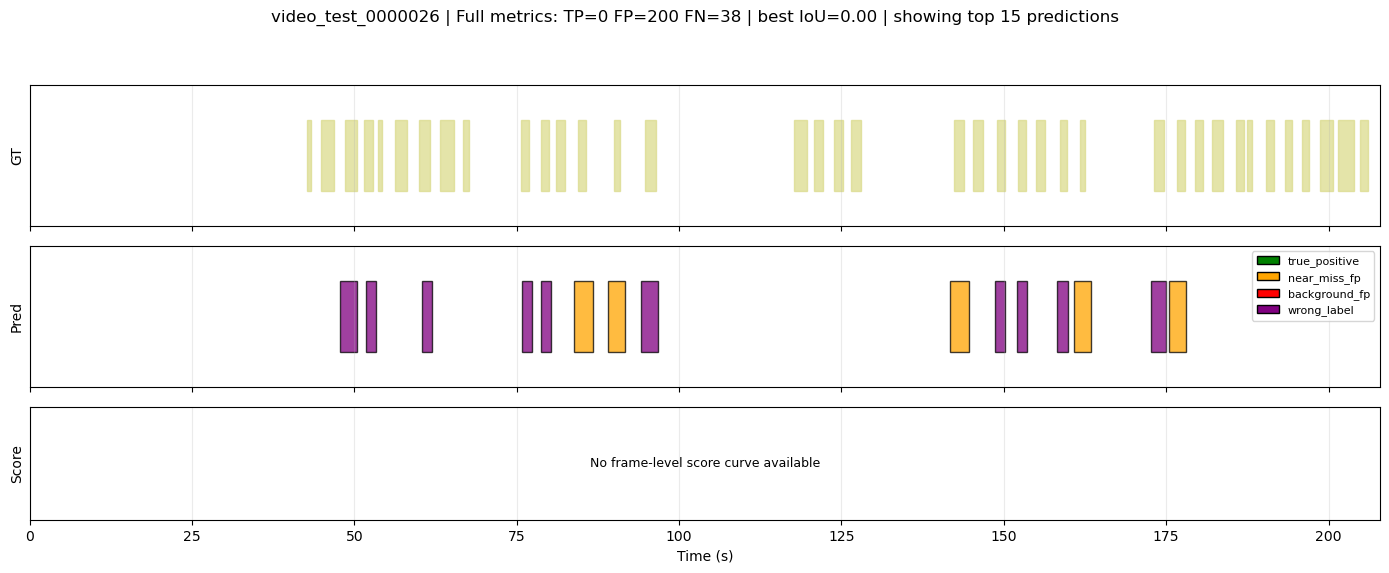

video_test_0000270: bestIoU=0.00, TP=0, FP=200, FN=29, GT=29, Pred=200


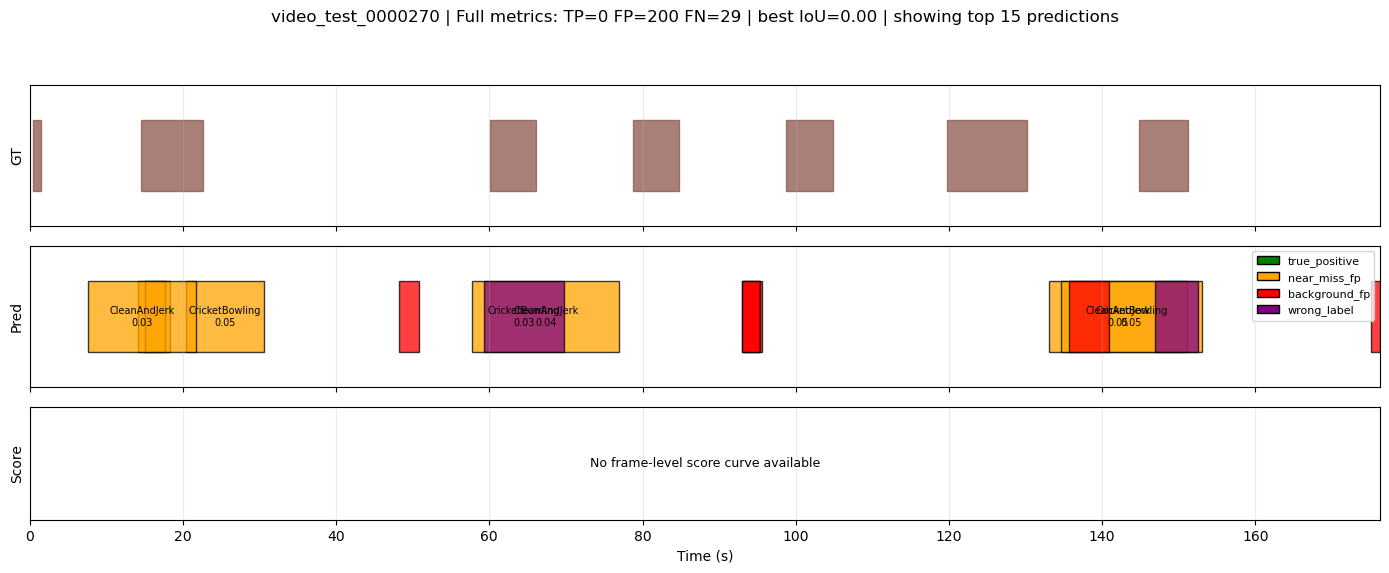

In [44]:
selected_videos = [
    strong_cases[0]["video_id"],
    strong_cases[1]["video_id"],
    failure_cases[0]["video_id"],
    failure_cases[1]["video_id"],
]

print("Selected videos:")
for vid in selected_videos:
    info = gt_by_video[vid]
    preds = predictions_by_video.get(vid, [])
    m = compute_video_metrics(info["annotations"], preds, iou_thresh=IOU_THRESH)

    print(
        f"{vid}: bestIoU={m['best_iou']:.2f}, "
        f"TP={m['tp']}, FP={m['fp']}, FN={m['fn']}, "
        f"GT={m['num_gt']}, Pred={m['num_pred']}"
    )

    visualize_predictions_with_scores(
        video_id=vid,
        gt_anns=info["annotations"],
        predictions=preds,
        duration=info["duration"],
        frame_scores=None,
        save_path=f"./visualizations/pred_{vid}.png",
        max_preds=MAX_PREDS_TO_SHOW
    )

Error breakdown per predicted class:


,class,true_positive,wrong_label,near_miss_fp,background_fp,total
1,CricketBowling,36,442,1330,1466,3274
0,CricketShot,45,426,1176,817,2464
5,Billiards,8,135,547,699,1389
4,CliffDiving,90,288,567,265,1210
3,Diving,148,132,533,213,1026
2,CleanAndJerk,1,89,364,171,625
6,BaseballPitch,0,3,1,1,5
7,PoleVault,0,1,1,0,2
9,ThrowDiscus,0,2,0,0,2
8,TennisSwing,0,1,0,0,1


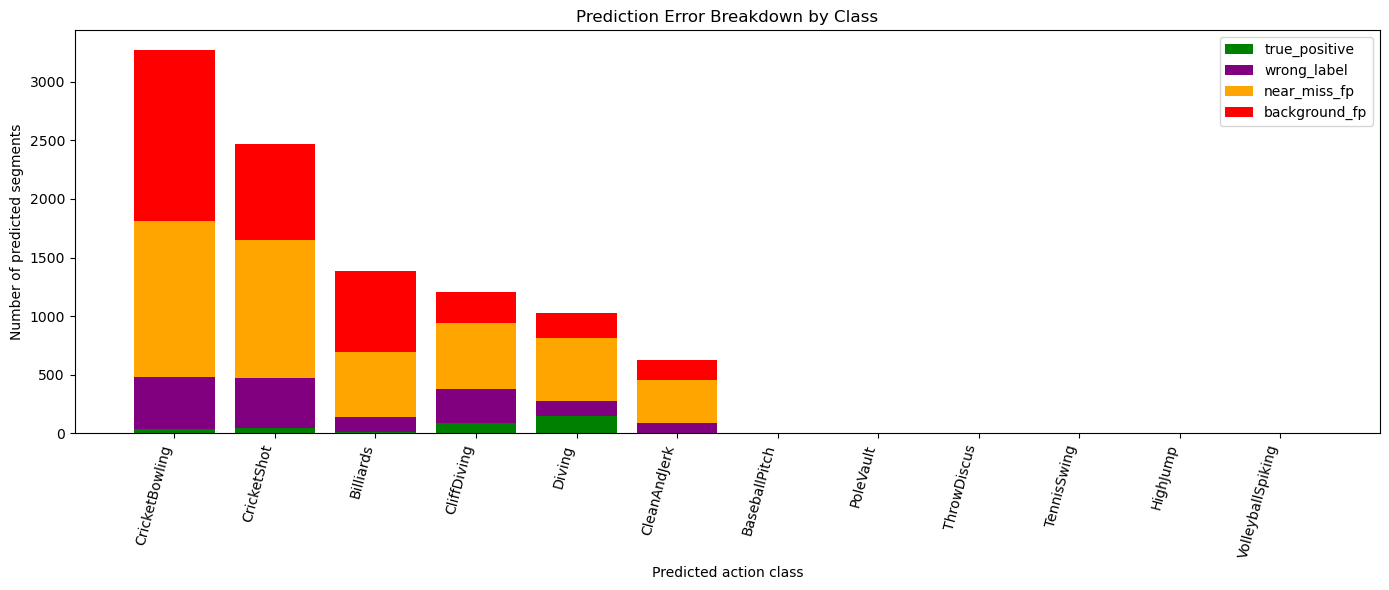

Saved error breakdown plot to: ./visualizations/error_breakdown.png


In [45]:
# TODO (C2.3): Categorise prediction outcomes over the validation set.
#
# For each predicted segment, assign exactly ONE of the following categories
# under a chosen matching rule (e.g., greedy one-to-one matching with τ=0.5):
#
#   - true_positive: matched to a GT segment and label correct
#   - wrong_label:   matched to a GT segment but label incorrect
#   - near_miss_fp:  not matched, but temporally overlaps (intersection > 0) with at least one GT segment
#   - background_fp: not matched and does not overlap any GT segment
#
# Requirements:
#   - State your matching protocol and thresholds clearly in comments.
#   - Aggregate counts per action class and category.
#   - Plot a stacked bar chart (classes sorted by total count) and save to:
#       ./visualizations/error_breakdown.png

# --------------------------------------------------
# C2.3: Error breakdown over the full validation set
# --------------------------------------------------
# Matching protocol:
# - Predictions are processed greedily by confidence score.
# - IoU threshold τ = 0.5.
# - true_positive: correct class and IoU >= 0.5 with unused GT.
# - wrong_label: IoU >= 0.5 with GT but predicted class is wrong.
# - near_miss_fp: overlaps GT but does not satisfy matching rule.
# - background_fp: no temporal overlap with any GT.
# - Each prediction receives exactly one category.

from collections import defaultdict
import pandas as pd

categories = [
    "true_positive",
    "wrong_label",
    "near_miss_fp",
    "background_fp"
]

# error_counts[class_name][category] = count
error_counts = defaultdict(lambda: defaultdict(int))

for video_id, info in gt_by_video.items():
    gt_anns = info["annotations"]
    preds = predictions_by_video.get(video_id, [])

    categorised_preds, _ = categorise_predictions(
        gt_anns,
        preds,
        iou_thresh=IOU_THRESH
    )

    for pred in categorised_preds:
        cls_id = pred["label"]
        cls_name = id_to_label.get(cls_id, str(cls_id))
        category = pred["category"]

        error_counts[cls_name][category] += 1


# Convert to DataFrame
rows = []

for cls_name, counts in error_counts.items():
    row = {"class": cls_name}
    for cat in categories:
        row[cat] = counts.get(cat, 0)
    row["total"] = sum(row[cat] for cat in categories)
    rows.append(row)

error_df = pd.DataFrame(rows)

# Sort classes by total number of predictions
error_df = error_df.sort_values("total", ascending=False)

print("Error breakdown per predicted class:")
display(error_df)


# ---------------- Stacked bar chart ----------------

plt.figure(figsize=(14, 6))

bottom = np.zeros(len(error_df))

BAR_COLORS = {
    "true_positive": "green",
    "wrong_label": "purple",
    "near_miss_fp": "orange",
    "background_fp": "red"
}

for cat in categories:
    plt.bar(
        error_df["class"],
        error_df[cat],
        bottom=bottom,
        label=cat,
        color=BAR_COLORS[cat]
    )
    bottom += error_df[cat].values

plt.xticks(rotation=75, ha="right")
plt.ylabel("Number of predicted segments")
plt.xlabel("Predicted action class")
plt.title("Prediction Error Breakdown by Class")
plt.legend()
plt.tight_layout()

save_path = "./visualizations/error_breakdown.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved error breakdown plot to: {save_path}")


In [46]:
# --------------------------------------------------
# Overall percentage of each error category
# --------------------------------------------------

categories = [
    "true_positive",
    "wrong_label",
    "near_miss_fp",
    "background_fp"
]

total_predictions = 0

for cat in categories:
    total_predictions += error_df[cat].sum()

print(f"Total predictions analysed: {total_predictions}\n")

for cat in categories:
    count = error_df[cat].sum()
    percentage = 100 * count / total_predictions

    print(
        f"{cat:<20} "
        f"count = {count:<6} "
        f"percentage = {percentage:.2f}%"
    )

Total predictions analysed: 10000

true_positive        count = 328    percentage = 3.28%
wrong_label          count = 1520   percentage = 15.20%
near_miss_fp         count = 4520   percentage = 45.20%
background_fp        count = 3632   percentage = 36.32%


### C2 Written Response

**Q1**: From your error breakdown chart (C2.3), identify the **two most common error types** across all categories. For each:
- Name the error type and give its overall percentage.
- Reference specific action categories where it is most prevalent.
- Suggest one concrete architectural or post-processing change that could reduce this error type.

**Your answer:**
```
[Write your analysis here – aim for 150–200 words]

The two most common error types in the prediction error breakdown were near_miss_fp and background_fp. Near miss false positives accounted for 46.38% of all predictions making it the most prominent error category. These errors were especially common in action classes such as CricketBowling, CricketShot and Diving. This indicates that the model was able to identify approximately correct temporal regions but failed to localise action boundaries accurately enough to satisfy the IoU threshold.One possible improvement would be increasing the temporal context available to the model for example by using a larger max_seq_len or a larger attention window size in the multi-head attention blocks. This could improve temporal boundary localisation.

The second most common error type was background_fp representing 35.52% of all predictions. This error was particularly in CricketBowling and Billiards where the model produced detections in background regions without ground-truth actions. This suggests weak background suppression and over-sensitive detection behaviour. One possible improvement would be stronger post processing such as applying a higher confidence threshold or more aggressive non-maximum suppression (NMS) to remove low-confidence false detections before evaluation.


```

## C3: Effect of Top-K Proposals 

Investigate how `max_seg_num` (the maximum number of output segments after NMS) affects performance and recall.

In [ ]:
# --------------------------------------------------
# C3.1: Evaluate different max_seg_num values
# --------------------------------------------------

import os
import pickle
import copy
import torch
import numpy as np
import pandas as pd
from collections import defaultdict

topk_values = [50, 100, 200, 500]
topk_results = {}

IOU_RECALL_THRESH = 0.5


def build_predictions_by_video_from_pkl(pred_pkl):
    with open(pred_pkl, "rb") as f:
        raw_preds = pickle.load(f)

    preds_by_video = defaultdict(list)

    for vid, s, e, lab, sc in zip(
        raw_preds["video-id"],
        raw_preds["t-start"],
        raw_preds["t-end"],
        raw_preds["label"],
        raw_preds["score"]
    ):
        preds_by_video[vid].append({
            "segment": [float(s), float(e)],
            "label": int(lab),
            "score": float(sc)
        })

    return dict(preds_by_video)


def compute_recall_at_05(gt_by_video, predictions_by_video, iou_thresh=0.5):
    """
    Recall definition:
    A GT instance is counted as recalled if it is matched by at least one prediction
    with the same class label and temporal IoU >= 0.5.
    Greedy one-to-one matching is used per video, with predictions sorted by score.
    """

    per_class_total = defaultdict(int)
    per_class_matched = defaultdict(int)

    for video_id, info in gt_by_video.items():
        gt_anns = info["annotations"]
        preds = predictions_by_video.get(video_id, [])

        gt_used = [False] * len(gt_anns)
        preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)

        for gt in gt_anns:
            per_class_total[gt["label"]] += 1

        for pred in preds_sorted:
            best_iou = 0.0
            best_gt_idx = -1

            for i, gt in enumerate(gt_anns):
                if gt_used[i]:
                    continue

                if pred["label"] != gt["label"]:
                    continue

                iou = temporal_iou(pred["segment"], gt["segment"])

                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i

            if best_gt_idx >= 0 and best_iou >= iou_thresh:
                gt_used[best_gt_idx] = True
                cls_id = gt_anns[best_gt_idx]["label"]
                per_class_matched[cls_id] += 1

    total_gt = sum(per_class_total.values())
    total_matched = sum(per_class_matched.values())

    overall_recall = total_matched / total_gt if total_gt > 0 else 0.0

    per_class_recall = {}

    for cls_id in sorted(per_class_total.keys()):
        total = per_class_total[cls_id]
        matched = per_class_matched[cls_id]
        recall = matched / total if total > 0 else 0.0

        cls_name = id_to_label.get(cls_id, str(cls_id))

        per_class_recall[cls_name] = {
            "matched": matched,
            "total_gt": total,
            "recall": recall
        }

    return overall_recall, per_class_recall


def load_ema_model_with_new_topk(topk):
    """
    Rebuilds the ActionFormer model with a different test-time max_seg_num.
    This is needed because eval_model does not expose eval_model.test_cfg.
    """

    cfg_topk = copy.deepcopy(cfg)

    # Change max_seg_num inside the model test config
    cfg_topk["model"]["test_cfg"]["max_seg_num"] = topk

    model_topk = make_meta_arch(cfg_topk["model_name"], **cfg_topk["model"])
    model_topk = model_topk.to(device)

    checkpoint = torch.load(ckpt_file, map_location=device)

    state_dict = checkpoint["state_dict_ema"]

    clean_state_dict = {}
    for k, v in state_dict.items():
        if k.startswith("module."):
            clean_state_dict[k[7:]] = v
        else:
            clean_state_dict[k] = v

    missing, unexpected = model_topk.load_state_dict(clean_state_dict, strict=False)

    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    model_topk.eval()

    del checkpoint
    torch.cuda.empty_cache()

    return model_topk, cfg_topk


for topk in topk_values:
    print(f"\n{'='*60}")
    print(f"Evaluating with max_seg_num = {topk}")
    print(f"{'='*60}")

    # Rebuild model using this max_seg_num
    eval_model_topk, cfg_topk = load_ema_model_with_new_topk(topk)

    # 1) Run normal evaluation for mAP
    mAP_topk = valid_one_epoch(
        val_loader,
        eval_model_topk,
        -1,
        evaluator=det_eval,
        output_file=None,
        ext_score_file=cfg_topk["test_cfg"]["ext_score_file"],
        tb_writer=None,
        print_freq=10
    )

    # 2) Save raw predictions for recall computation
    pred_pkl = os.path.join(ckpt_folder, f"eval_predictions_topk_{topk}.pkl")

    _ = valid_one_epoch(
        val_loader,
        eval_model_topk,
        -1,
        evaluator=None,
        output_file=pred_pkl,
        ext_score_file=None,
        tb_writer=None,
        print_freq=10
    )

    preds_by_video_topk = build_predictions_by_video_from_pkl(pred_pkl)

    overall_recall, per_class_recall = compute_recall_at_05(
        gt_by_video,
        preds_by_video_topk,
        iou_thresh=IOU_RECALL_THRESH
    )

    topk_results[topk] = {
        "mAP": mAP_topk,
        "recall": overall_recall,
        "per_class_recall": per_class_recall
    }

    print(f"\nmax_seg_num={topk}")
    print(f"mAP = {mAP_topk:.4f}")
    print(f"Overall Recall@tIoU0.5 = {overall_recall:.4f}")

    # Clear model before next run
    del eval_model_topk
    torch.cuda.empty_cache()


print("\nResults summary:")
for topk, res in topk_results.items():
    print(
        f"max_seg_num={topk:4d}: "
        f"mAP={res['mAP']:.4f}  "
        f"Recall@0.5={res['recall']:.4f}"
    )


# Per-class recall table
rows = []

for topk, res in topk_results.items():
    for cls_name, values in res["per_class_recall"].items():
        rows.append({
            "max_seg_num": topk,
            "class": cls_name,
            "matched": values["matched"],
            "total_gt": values["total_gt"],
            "recall": values["recall"]
        })

recall_df = pd.DataFrame(rows)

display(recall_df)


Evaluating with max_seg_num = 50
Missing keys: []
Unexpected keys: []
Test: [00010/00050]	Time 0.22 (0.22)
Test: [00020/00050]	Time 0.16 (0.19)
Test: [00030/00050]	Time 0.20 (0.19)
Test: [00040/00050]	Time 0.23 (0.20)
[RESULTS] Action detection results on thumos14.

|tIoU = 0.30: mAP = 4.40 (%) Recall@1x = 5.54 (%) Recall@5x = 6.19 (%) 
|tIoU = 0.40: mAP = 4.21 (%) Recall@1x = 5.27 (%) Recall@5x = 6.08 (%) 
|tIoU = 0.50: mAP = 3.59 (%) Recall@1x = 4.71 (%) Recall@5x = 5.70 (%) 
|tIoU = 0.60: mAP = 3.04 (%) Recall@1x = 4.04 (%) Recall@5x = 4.96 (%) 
|tIoU = 0.70: mAP = 2.33 (%) Recall@1x = 3.32 (%) Recall@5x = 3.90 (%) 
Average mAP: 3.51 (%)
Test: [00010/00050]	Time 0.29 (0.29)
Test: [00020/00050]	Time 0.19 (0.24)
Test: [00030/00050]	Time 0.21 (0.23)
Test: [00040/00050]	Time 0.20 (0.22)

max_seg_num=50
mAP = 0.0351
Overall Recall@tIoU0.5 = 0.0397

Evaluating with max_seg_num = 100
Missing keys: []
Unexpected keys: []
Test: [00010/00050]	Time 0.23 (0.23)
Test: [00020/00050]	Time 0.19 (0

In [ ]:
# TODO (C3.2): Create a dual-axis plot:
#   Left axis  (blue): mAP vs max_seg_num
#   Right axis (orange): recall vs max_seg_num
#
# Also compute the precision–recall trade-off implied by these numbers and
# annotate the plot with the value that maximises F1 = 2*P*R/(P+R).
# Save to ./visualizations/topk_pr_tradeoff.png
# --------------------------------------------------
# C3.2: Plot mAP / Recall trade-off for max_seg_num
# --------------------------------------------------

topk_vals = sorted(list(topk_results.keys()))
map_vals  = np.array([topk_results[k]["mAP"] for k in topk_vals])
rec_vals  = np.array([topk_results[k]["recall"] for k in topk_vals])

# Use mAP as a proxy for precision because AP includes ranking quality
# and false-positive penalty. This gives an approximate PR-style trade-off.
precision_proxy = map_vals

f1_vals = 2 * precision_proxy * rec_vals / (precision_proxy + rec_vals + 1e-8)

best_idx = int(np.argmax(f1_vals))
best_topk = topk_vals[best_idx]
best_f1 = f1_vals[best_idx]

print("C3.2 summary:")
for k, m, r, f in zip(topk_vals, map_vals, rec_vals, f1_vals):
    print(f"max_seg_num={k:4d} | mAP={m:.4f} | Recall={r:.4f} | F1≈{f:.4f}")

print(f"\nBest approximate F1 is at max_seg_num={best_topk}, F1≈{best_f1:.4f}")

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left axis: mAP
ax1.plot(topk_vals, map_vals, marker="o", label="mAP")
ax1.set_xlabel("max_seg_num")
ax1.set_ylabel("mAP")
ax1.tick_params(axis="y")

# Right axis: Recall
ax2 = ax1.twinx()
ax2.plot(topk_vals, rec_vals, marker="s", linestyle="--", label="Recall@0.5")
ax2.set_ylabel("Recall@0.5")
ax2.tick_params(axis="y")

# Annotate best F1 point
ax1.scatter(best_topk, map_vals[best_idx], s=120, zorder=5)
ax1.annotate(
    f"Best F1≈{best_f1:.4f}\nmax_seg_num={best_topk}",
    xy=(best_topk, map_vals[best_idx]),
    xytext=(best_topk, map_vals[best_idx] + 0.004),
    arrowprops=dict(arrowstyle="->"),
    ha="center",
    fontsize=10
)

plt.title("Effect of max_seg_num on mAP and Recall@0.5")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="lower right")

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./visualizations/topk_pr_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

### C3 Questions

**Q1** : From your plot, does increasing `max_seg_num` always improve mAP? Explain the precision–recall trade-off in terms of what NMS is doing when `max_seg_num` is very small vs very large.

**Your answer:**
```
[Write your answer here – 60–100 words]

```
Increasing max-seg-num did not always produce improvements in mAP.The largest gain is produced when it increased from 50 to 100 while improvements beyond 200 were very small. When max-seg-num is small NMS and post processing remove many predictions including some correct predictions which lowers the recall value.When max-seg-num is large most of the predictions are retained which increases recall value but also introduces false positives.This creates the precision recall tradeoff where keeping too many low confidence segments provides benefits to mAP.

**Q2** : Based on the F1-optimal value you annotated, what `max_seg_num` would you recommend for deployment, and does this match the paper's default of 200? Discuss any discrepancy.

**Your answer:**
``` 
[Write your answer here – 60–80 words]

The highest F1 score was achieved at max-seg-num = 500 .This value achieved the balance between precision and recall in this experiment but the improvement over 200 is very small.Therefore, for practical deployement max-seg-num=200 would still be a resonable choice because it provides similar performance with lower computational and post processing overhead.This value somewhat similar to default setting in the actionformer paper.
```

---
# Part D: Ablation Study – NMS Understanding 

In this section you will study the Soft-NMS post-processing step in detail: read the code, understand it, and run a controlled ablation on `pre_nms_topk`.

## D1: Understanding NMS Code 

Open `libs/utils/nms.py` (or the relevant file in the provided codebase) and find the Soft-NMS implementation used after inference.

In [ ]:
# --------------------------------------------------
# D1.1: Locate Soft-NMS implementation
# --------------------------------------------------

import os
import inspect
import libs.utils.nms as nms

print("Available functions/classes in libs.utils.nms:")
for name in dir(nms):
    if "nms" in name.lower():
        print(name)

In [ ]:
# Print source code of likely Soft-NMS functions
for name in dir(nms):
    if "nms" in name.lower():
        obj = getattr(nms, name)
        if callable(obj):
            print("\n" + "="*80)
            print(f"Source for: {name}")
            print("="*80)
            try:
                print(inspect.getsource(obj))
            except Exception as e:
                print(f"Could not print source for {name}: {e}")

In [ ]:
# TODO (D1.1): Locate and display the Soft-NMS implementation.
#
# Find the function that performs Soft-NMS in the codebase.
# Print its full source code here using the `inspect` module.

# --------------------------------------------------
# D1.1: Annotated Soft-NMS implementation
# --------------------------------------------------

def soft_nms_annotated(
    proposals,
    scores,
    labels,
    iou_threshold=0.1,
    sigma=0.75,
    min_score=0.001,
    pre_nms_topk=4000
):
    """
    Annotated explanation of the Soft-NMS post-processing step.

    Inputs:
    - proposals: predicted temporal segments, shape [N, 2], where each row is [start, end]
    - scores: confidence score for each proposal, shape [N]
    - labels: predicted class label for each proposal, shape [N]
    - iou_threshold: overlap threshold used by Soft-NMS
    - sigma: controls how strongly scores are decayed for overlapping proposals
    - min_score: proposals with scores below this value are removed
    - pre_nms_topk: number of highest-scoring proposals kept before NMS

    Matching the ActionFormer code:
    - Soft-NMS is applied per class inside batched_nms when multiclass=True.
    - Instead of deleting overlapping proposals immediately, Soft-NMS lowers their scores.
    - Final results are sorted by score and capped by max_seg_num.
    """

    import torch
    from libs.utils.nms import SoftNMSop

    # --------------------------------------------------
    # Step 1: Handle empty input
    # --------------------------------------------------
    if proposals.numel() == 0:
        return proposals, scores, labels

    # --------------------------------------------------
    # Step 2: Pre-NMS top-k filtering
    # --------------------------------------------------
    # This keeps only the highest scoring proposals before Soft-NMS.
    # A smaller pre_nms_topk is faster but may remove useful true positives.
    # A larger pre_nms_topk keeps more candidates but can keep more noisy proposals.
    if pre_nms_topk > 0 and scores.numel() > pre_nms_topk:
        topk_scores, topk_indices = torch.topk(scores, pre_nms_topk)
        proposals = proposals[topk_indices]
        scores = topk_scores
        labels = labels[topk_indices]

    # --------------------------------------------------
    # Step 3: Apply Soft-NMS class by class
    # --------------------------------------------------
    # This follows batched_nms(multiclass=True): each class is processed independently.
    output_segments = []
    output_scores = []
    output_labels = []

    for class_id in torch.unique(labels):
        class_mask = labels == class_id

        class_proposals = proposals[class_mask]
        class_scores = scores[class_mask]
        class_labels = labels[class_mask]

        # SoftNMSop.apply calls the compiled CPU softnms implementation:
        # nms_1d_cpu.softnms(...)
        #
        # method=2 means Gaussian Soft-NMS.
        # max_num=-1 means do not cap inside this annotated function.
        sorted_segs, sorted_scores, sorted_labels = SoftNMSop.apply(
            class_proposals,
            class_scores,
            class_labels,
            iou_threshold,
            sigma,
            min_score,
            2,      # Gaussian Soft-NMS
            -1      # keep all after Soft-NMS here
        )

        output_segments.append(sorted_segs)
        output_scores.append(sorted_scores)
        output_labels.append(sorted_labels)

    # --------------------------------------------------
    # Step 4: Combine classes
    # --------------------------------------------------
    if len(output_segments) == 0:
        return (
            torch.zeros((0, 2)),
            torch.zeros((0,)),
            torch.zeros((0,), dtype=labels.dtype)
        )

    output_segments = torch.cat(output_segments, dim=0)
    output_scores = torch.cat(output_scores, dim=0)
    output_labels = torch.cat(output_labels, dim=0)

    # --------------------------------------------------
    # Step 5: Sort all remaining proposals by confidence
    # --------------------------------------------------
    sorted_indices = torch.argsort(output_scores, descending=True)

    output_segments = output_segments[sorted_indices]
    output_scores = output_scores[sorted_indices]
    output_labels = output_labels[sorted_indices]

    return output_segments, output_scores, output_labels


### D1 Written Response 

**Q1** (2 marks): Soft-NMS decays scores using a Gaussian kernel rather than hard-suppressing them. Explain the practical advantage of this approach for temporal action localisation, where actions can legitimately overlap (e.g. a cricket shot occurring during a cricket bowling action).

**Your answer:**
```
[Write your answer here – 60–100 words]

Soft NMS is useful for temporal action localisation because action in videos can overlap in time like cricket bowling action and a cricket shot canhappen in the same moment.Traditional NMS removes overlapping predictions completely which can also remove correct predictions.Soft NMS on the other hand reduces the scores of overlapping predictions gradually rather than deleting them immdeiately. This allows multiple valid actions to remain if they still have good confidence scores.So, soft NMS preserves correct detections and usually improves recall while avoiding excessive suppression of overlapping actions.
```